In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("https://raw.githubusercontent.com/iddadobroc/PDS_Airport_Analysis/refs/heads/main/avia_par_pt_annual_linear_2_0.csv")


In [15]:
df.shape

(57789, 19)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57789 entries, 0 to 57788
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               57789 non-null  object 
 1   STRUCTURE_ID                            57789 non-null  object 
 2   STRUCTURE_NAME                          57789 non-null  object 
 3   freq                                    57789 non-null  object 
 4   Time frequency                          57789 non-null  object 
 5   unit                                    57789 non-null  object 
 6   Unit of measure                         57789 non-null  object 
 7   tra_meas                                57789 non-null  object 
 8   Traffic and transport measurement       57789 non-null  object 
 9   airp_pr                                 57789 non-null  object 
 10  Airport pairs (routes)                  57789 non-null  ob

## Initial Dataset Inspection

The analysis begins with a preliminary inspection of the original Eurostat dataset.

At this stage, we evaluate:
- the overall dataset dimensions,
- column data types,
- missing values,
- and the general structure of the available variables.

This initial exploration is essential to identify potential data quality issues before starting the cleaning and transformation pipeline.

In [17]:
df.dropna(axis=1, inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57789 entries, 0 to 57788
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   STRUCTURE                          57789 non-null  object
 1   STRUCTURE_ID                       57789 non-null  object
 2   STRUCTURE_NAME                     57789 non-null  object
 3   freq                               57789 non-null  object
 4   Time frequency                     57789 non-null  object
 5   unit                               57789 non-null  object
 6   Unit of measure                    57789 non-null  object
 7   tra_meas                           57789 non-null  object
 8   Traffic and transport measurement  57789 non-null  object
 9   airp_pr                            57789 non-null  object
 10  Airport pairs (routes)             57789 non-null  object
 11  TIME_PERIOD                        57789 non-null  int64 
 12  OBS_

In [19]:
df.nunique()

,0
STRUCTURE,1
STRUCTURE_ID,1
STRUCTURE_NAME,1
freq,1
Time frequency,1
unit,3
Unit of measure,3
tra_meas,12
Traffic and transport measurement,12
airp_pr,513


In [20]:
df.sample(20)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE
6316,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPMA_DK_EKCH,MADEIRA airport - KOBENHAVN/KASTRUP airport,2023,84
45957,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPR_BR_SBGR,"PORTO airport - SAO PAULO/GUARULHOS, GOVERNADO...",2008,79150
41641,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPR_MA_GMMX,PORTO AIRPORT - MARRAKECH/MENARA AIRPORT,2024,56352
5812,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPFU_DE_EDDH,FUNCHAL/MADEIRA I. airport - HAMBURG airport,2005,52
34231,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPFR_UK_EGGA,FARO airport - LONDON (CAA HQ) airport,2003,91745
9591,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPFR_DE_EDDM,FARO airport - MUENCHEN airport,2022,296
4081,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_IE_EIDW,LISBOA airport - DUBLIN airport,2014,1239
50797,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPPR_DE_EDDF,PORTO airport - FRANKFURT/MAIN airport,2008,184634
34882,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPLA_PT_LPPD,LAJES airport - PONTA DELGADA airport,2018,92483
2548,dataflow,ESTAT:AVIA_PAR_PT(1.0),Air passenger transport routes between partner...,A,Annual,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPR_ES_GCTS,PORTO airport - TENERIFE SUR/REINA SOFIA airport,2006,164


In [21]:
df.drop(columns = ["STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "freq","Time frequency"], inplace = True)

## Removal of Empty and Non-Informative Columns

During the initial inspection of the dataset, several columns were identified as either completely empty or non-informative for the analysis.

First, columns containing only missing values (`NaN`) were removed, since they provided no usable information.

Additionally, some metadata-related columns contained only a single constant value across the entire dataset, meaning they introduced no variability and no analytical value. They include:

- `STRUCTURE`
- `STRUCTURE_ID`
- `STRUCTURE_NAME`
- `freq`
- `Time frequency`

Because these variables were constant for all observations, they were removed to simplify the dataset structure, reduce unnecessary dimensionality, and improve the readability of the analytical pipeline.

In [22]:
df.sample(20)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE
9774,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPFR_FI_EFKL,FARO airport - HELSINKI (MET INSTITUTE) airport,2002,62
1862,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPMA_UK_EGCC,MADEIRA airport - MANCHESTER airport,2023,994
29641,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPHR_PT_LPFL,HORTA airport - FLORES airport,2014,19411
50040,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPMA_LU_ELLX,MADEIRA airport - LUXEMBOURG airport,2016,13830
40168,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPMA_DE_EDDM,MADEIRA airport - MUENCHEN airport,2013,18960
7192,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPR_DE_EDDM,PORTO airport - MUENCHEN airport,2024,603
57737,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPPT_US_KEWR,"LISBOA airport - NEWARK LIBERTY INTERNATIONAL,...",2016,145049
4108,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_IT_LIMC,LISBOA airport - MILANO/MALPENSA airport,2012,2489
23745,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPFR_DE_EDDM,FARO airport - MUENCHEN airport,2019,41402
17315,PAS,Passenger,PAS_BRD,Passengers on board,PT_LPPS_PT_LPPR,PORTO SANTO airport - PORTO airport,2016,11659


In [64]:
# Create copy

df_routes = df.copy()

# Extract full airport codes directly from airp_pr

df_routes[
    [
        "airport_pt_code",
        "airport_nonpt_code"
    ]
] = (
    df_routes["airp_pr"]
    .str.extract(
        r"(PT_[A-Z]{4})_([A-Z]{2}_[A-Z]{4})"
    )
)

## Extraction of Airport Codes

The original Eurostat route identifier (`airp_pr`) contains encoded airport pairs combining Portuguese and non-Portuguese airport codes.

Using regular expressions, the route identifiers were decomposed into:
- Portuguese airport codes (`airport_pt_code`)
- non-Portuguese airport codes (`airport_nonpt_code`)

This transformation allows route-level standardization and simplifies downstream analysis.

In [65]:
df_routes.sample(20)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport_pt_code,airport_nonpt_code
21498,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_FR_LFBO,PORTO airport - TOULOUSE/BLAGNAC airport,2016,27875,PT_LPPR,FR_LFBO
26025,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_DE_EDDF,PORTO airport - FRANKFURT/MAIN airport,2016,159689,PT_LPPR,DE_EDDF
3683,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_DE_EDDH,LISBOA airport - HAMBURG airport,2011,1138,PT_LPPT,DE_EDDH
49671,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPLA_PT_LPHR,LAJES airport - HORTA airport,2017,43457,PT_LPLA,PT_LPHR
46809,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPS_PT_LPFU,"PORTO SANTO airport - FUNCHAL, MADEIRA I. airport",2001,140243,PT_LPPS,PT_LPFU
26205,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_ES_LEPM,PORTO airport - PALMA DE MALLORCA (OFICINA MET...,2006,75681,PT_LPPR,ES_LEPM
49028,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPFR_UK_EGBB,FARO airport - BIRMINGHAM airport,1999,80603,PT_LPFR,UK_EGBB
21153,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_BE_EBCI,PORTO airport - CHARLEROI/BRUSSELS SOUTH airport,2020,27759,PT_LPPR,BE_EBCI
52352,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPPT_FR_LFPG,LISBOA airport - PARIS-CHARLES DE GAULLE airport,2009,399888,PT_LPPT,FR_LFPG
54742,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPMA_FR_LFPO,MADEIRA airport - PARIS-ORLY airport,2016,89361,PT_LPMA,FR_LFPO


In [66]:
# Split only on first occurrence of " - "

route_split = (
    df_routes["Airport pairs (routes)"]
    .str.split(" - ", n=1, expand=True)
)

# Assign columns

df_routes["airport_pt_name"] = route_split[0]
df_routes["airport_nonpt_name"] = route_split[1]

## Extraction of Airport Names

The textual route descriptions were split into separate airport names for Portuguese and non-Portuguese airports.

This step enables:
- independent airport-level analysis,
- route normalization,
- and consistency checks between airport names and airport codes.

In [68]:
df_routes.sample(20)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport_pt_code,airport_nonpt_code,airport_pt_name,airport_nonpt_name
4923,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPFR_DE_EDDS,FARO airport - STUTTGART airport,2009,164,PT_LPFR,DE_EDDS,FARO airport,STUTTGART airport
21296,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_DE_EDDF,PORTO airport - FRANKFURT/MAIN airport,2019,226427,PT_LPPR,DE_EDDF,PORTO airport,FRANKFURT/MAIN airport
28544,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPFR_DE_EDDS,FARO airport - STUTTGART airport,2014,47979,PT_LPFR,DE_EDDS,FARO airport,STUTTGART airport
36818,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPS_IT_LIMC,PORTO SANTO airport - MILANO/MALPENSA airport,2016,6501,PT_LPPS,IT_LIMC,PORTO SANTO airport,MILANO/MALPENSA airport
12073,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPPR_FR_LFLL,PORTO airport - LYON SAINT-EXUPERY airport,2012,268,PT_LPPR,FR_LFLL,PORTO airport,LYON SAINT-EXUPERY airport
16318,PAS,Passenger,PAS_BRD,Passengers on board,PT_LPPD_PT_LPSJ,PONTA DELGADA airport - SAO JORGE airport,2021,20262,PT_LPPD,PT_LPSJ,PONTA DELGADA airport,SAO JORGE airport
37761,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT_FR_LFRS,LISBOA airport - NANTES ATLANTIQUE airport,2022,87934,PT_LPPT,FR_LFRS,LISBOA airport,NANTES ATLANTIQUE airport
28630,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPFR_DE_EDSO,FARO airport - FRANKFURT airport,2009,49713,PT_LPFR,DE_EDSO,FARO airport,FRANKFURT airport
5391,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPFR_UK_EGAC,FARO airport - BELFAST/CITY airport,2015,581,PT_LPFR,UK_EGAC,FARO airport,BELFAST/CITY airport
55901,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPPR_FR_LFSB,PORTO airport - BALE-MULHOUSE airport,2022,115131,PT_LPPR,FR_LFSB,PORTO airport,BALE-MULHOUSE airport


## Detection of Naming and Coding Inconsistencies

Before performing any aggregation, consistency checks were conducted between airport codes and airport names.

The objective of this validation step was to identify:
- multiple airport names associated with the same code,
- multiple codes associated with the same airport,
- typographical inconsistencies,
- and possible reporting anomalies in the original Eurostat data.

These checks are crucial because inconsistent airport identifiers would artificially fragment routes and bias subsequent aggregations.

In [69]:
pt_code_inconsistencies = (
    df_routes
    .groupby("airport_pt_code")["airport_pt_name"]
    .nunique()
    .reset_index()
)

pt_code_inconsistencies = (
    pt_code_inconsistencies[
        pt_code_inconsistencies["airport_pt_name"] > 1
    ]
)

print(pt_code_inconsistencies)

  airport_pt_code  airport_pt_name
0         PT_LPFR                2
3         PT_LPLA                2
4         PT_LPMA                2
5         PT_LPPD                2
7         PT_LPPR                2
9         PT_LPPT                2


In [70]:
nonpt_code_inconsistencies = (
    df_routes
    .groupby("airport_nonpt_code")["airport_nonpt_name"]
    .nunique()
    .reset_index()
)

nonpt_code_inconsistencies = (
    nonpt_code_inconsistencies[
        nonpt_code_inconsistencies["airport_nonpt_name"] > 1
    ]
)

print(nonpt_code_inconsistencies)

    airport_nonpt_code  airport_nonpt_name
29             CA_CYUL                   2
30             CA_CYYZ                   2
32             CH_LSGG                   2
52             DE_EDDP                   2
77             DK_EKCH                   2
82             ES_GCLP                   2
84             ES_GCTS                   2
92             ES_LEMD                   2
102            FR_LFBD                   2
131            IT_LIRF                   2
139            MA_GMMX                   2
154            PT_LPFR                   2
181            UK_EGBB                   2


In [71]:
pt_name_inconsistencies = (
    df_routes
    .groupby("airport_pt_name")["airport_pt_code"]
    .nunique()
    .reset_index()
)

pt_name_inconsistencies = (
    pt_name_inconsistencies[
        pt_name_inconsistencies["airport_pt_code"] > 1
    ]
)

print(pt_name_inconsistencies)

Empty DataFrame
Columns: [airport_pt_name, airport_pt_code]
Index: []


In [72]:
nonpt_name_inconsistencies = (
    df_routes
    .groupby("airport_nonpt_name")["airport_nonpt_code"]
    .nunique()
    .reset_index()
)

nonpt_name_inconsistencies = (
    nonpt_name_inconsistencies[
        nonpt_name_inconsistencies["airport_nonpt_code"] > 1
    ]
)

print(nonpt_name_inconsistencies)

        airport_nonpt_name  airport_nonpt_code
10   BALE-MULHOUSE airport                   2
63       EDINBURGH airport                   2
92         HAMBURG airport                   2
142      MEMMINGEN airport                   2
189      PRESTWICK airport                   2


In [73]:
df_routes[
    df_routes["airport_pt_code"].isin([
        "PT_LPFR",
        "PT_LPLA",
        "PT_LPMA",
        "PT_LPPD",
        "PT_LPPR",
        "PT_LPPT"
    ])
][
    [
        "airport_pt_code",
        "airport_pt_name"
    ]
].drop_duplicates().sort_values(
    ["airport_pt_code", "airport_pt_name"]
)

,airport_pt_code,airport_pt_name
51,PT_LPFR,FARO AIRPORT
0,PT_LPFR,FARO airport
1308,PT_LPLA,LAJES AIRPORT
1309,PT_LPLA,LAJES airport
1465,PT_LPMA,MADEIRA AIRPORT
1435,PT_LPMA,MADEIRA airport
1953,PT_LPPD,PONTA DELGADA AIRPORT
1954,PT_LPPD,PONTA DELGADA airport
2541,PT_LPPR,PORTO AIRPORT
2279,PT_LPPR,PORTO airport


## Standardization of Airport Names

Airport names were normalized to improve consistency across observations.

The standardization process included:
- conversion to uppercase,
- removal of leading and trailing spaces,
- and normalization of repeated whitespace characters.

This step reduces duplicate representations caused by formatting inconsistencies.

In [74]:
# Normalize PT airport names

df_routes["airport_pt_name"] = (
    df_routes["airport_pt_name"]
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Normalize non-PT airport names

df_routes["airport_nonpt_name"] = (
    df_routes["airport_nonpt_name"]
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [75]:
(
    df_routes
    .groupby("airport_pt_code")["airport_pt_name"]
    .nunique()
    .sort_values(ascending=False)
)

,airport_pt_name
airport_pt_code,
PT_LPFR,1
PT_LPFU,1
PT_LPHR,1
PT_LPLA,1
PT_LPMA,1
PT_LPPD,1
PT_LPPI,1
PT_LPPR,1
PT_LPPS,1


In [76]:
pt_code_inconsistencies = (
    df_routes
    .groupby("airport_pt_code")["airport_pt_name"]
    .nunique()
    .reset_index()
)

pt_code_inconsistencies = (
    pt_code_inconsistencies[
        pt_code_inconsistencies["airport_pt_name"] > 1
    ]
)

print(pt_code_inconsistencies)

Empty DataFrame
Columns: [airport_pt_code, airport_pt_name]
Index: []


In [77]:
nonpt_code_inconsistencies = (
    df_routes
    .groupby("airport_nonpt_code")["airport_nonpt_name"]
    .nunique()
    .reset_index()
)

nonpt_code_inconsistencies = (
    nonpt_code_inconsistencies[
        nonpt_code_inconsistencies["airport_nonpt_name"] > 1
    ]
)

print(nonpt_code_inconsistencies)

Empty DataFrame
Columns: [airport_nonpt_code, airport_nonpt_name]
Index: []


In [78]:
nonpt_name_inconsistencies = (
    df_routes
    .groupby("airport_nonpt_name")["airport_nonpt_code"]
    .nunique()
    .reset_index()
)

nonpt_name_inconsistencies = (
    nonpt_name_inconsistencies[
        nonpt_name_inconsistencies["airport_nonpt_code"] > 1
    ]
)

print(nonpt_name_inconsistencies)

        airport_nonpt_name  airport_nonpt_code
9    BALE-MULHOUSE AIRPORT                   2
60       EDINBURGH AIRPORT                   2
86         HAMBURG AIRPORT                   2
133      MEMMINGEN AIRPORT                   2
179      PRESTWICK AIRPORT                   2


In [79]:
problem_names = [
    "BALE-MULHOUSE AIRPORT",
    "EDINBURGH AIRPORT",
    "HAMBURG AIRPORT",
    "MEMMINGEN AIRPORT",
    "PRESTWICK AIRPORT"
]

df_routes[
    df_routes["airport_nonpt_name"].isin(problem_names)
][
    [
        "airport_nonpt_name",
        "airport_nonpt_code"
    ]
].drop_duplicates().sort_values(
    ["airport_nonpt_name", "airport_nonpt_code"]
)

,airport_nonpt_name,airport_nonpt_code
1464,BALE-MULHOUSE AIRPORT,CH_LFSB
452,BALE-MULHOUSE AIRPORT,FR_LFSB
1003,EDINBURGH AIRPORT,UK_EGPH
1038,EDINBURGH AIRPORT,UK_EGQT
109,HAMBURG AIRPORT,DE_EDDH
276,HAMBURG AIRPORT,DE_EDHA
277,MEMMINGEN AIRPORT,DE_EDJA
2527,MEMMINGEN AIRPORT,DE_EDSM
1023,PRESTWICK AIRPORT,UK_EGPK
1033,PRESTWICK AIRPORT,UK_EGQG


In [80]:
problem_airports = [
    "BALE-MULHOUSE AIRPORT",
    "EDINBURGH AIRPORT",
    "HAMBURG AIRPORT",
    "MEMMINGEN AIRPORT",
    "PRESTWICK AIRPORT"
]

(
    df_routes[
        df_routes["airport_nonpt_name"].isin(problem_airports)
    ]
    .groupby(
        [
            "airport_nonpt_name",
            "airport_nonpt_code"
        ]
    )
    .size()
    .reset_index(name="records")
    .sort_values(
        ["airport_nonpt_name", "records"],
        ascending=[True, False]
    )
)

,airport_nonpt_name,airport_nonpt_code,records
1,BALE-MULHOUSE AIRPORT,FR_LFSB,324
0,BALE-MULHOUSE AIRPORT,CH_LFSB,108
2,EDINBURGH AIRPORT,UK_EGPH,339
3,EDINBURGH AIRPORT,UK_EGQT,48
4,HAMBURG AIRPORT,DE_EDDH,576
5,HAMBURG AIRPORT,DE_EDHA,24
6,MEMMINGEN AIRPORT,DE_EDJA,132
7,MEMMINGEN AIRPORT,DE_EDSM,24
8,PRESTWICK AIRPORT,UK_EGPK,120
9,PRESTWICK AIRPORT,UK_EGQG,60


## Manual Correction of Airport Code Inconsistencies

After the automatic consistency checks, several airport codes were identified as incorrect, duplicated, or inconsistently assigned.

These inconsistencies likely originate from:
- historical reporting changes,
- airport authority differences,
- FIR/control-area identifiers,
- or Eurostat recording anomalies.

Manual corrections were therefore applied to harmonize airport identifiers and ensure that the same physical airport is consistently represented by a single code.

In [81]:
df_routes["airport_nonpt_code"] = (
    df_routes["airport_nonpt_code"]
    .replace({
        "CH_LFSB": "FR_LFSB",
        "UK_EGQT": "UK_EGPH",
        "DE_EDHA": "DE_EDDH",
        "DE_EDSM": "DE_EDJA",
        "UK_EGQG": "UK_EGPK"
    })
)

In [82]:
nonpt_name_inconsistencies = (
    df_routes
    .groupby("airport_nonpt_name")["airport_nonpt_code"]
    .nunique()
    .reset_index()
)

nonpt_name_inconsistencies = (
    nonpt_name_inconsistencies[
        nonpt_name_inconsistencies["airport_nonpt_code"] > 1
    ]
)

print(nonpt_name_inconsistencies)

Empty DataFrame
Columns: [airport_nonpt_name, airport_nonpt_code]
Index: []


In [83]:
problem_names = [
    "BALE-MULHOUSE AIRPORT",
    "EDINBURGH AIRPORT",
    "HAMBURG AIRPORT",
    "MEMMINGEN AIRPORT",
    "PRESTWICK AIRPORT"
]

df_routes[
    df_routes["airport_nonpt_name"].isin(problem_names)
][
    [
        "airport_nonpt_name",
        "airport_nonpt_code"
    ]
].drop_duplicates().sort_values(
    ["airport_nonpt_name", "airport_nonpt_code"]
)

,airport_nonpt_name,airport_nonpt_code
452,BALE-MULHOUSE AIRPORT,FR_LFSB
1003,EDINBURGH AIRPORT,UK_EGPH
109,HAMBURG AIRPORT,DE_EDDH
277,MEMMINGEN AIRPORT,DE_EDJA
1023,PRESTWICK AIRPORT,UK_EGPK


In [84]:
df_routes.sample(20)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport_pt_code,airport_nonpt_code,airport_pt_name,airport_nonpt_name
9636,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPFR_DE_EDDT,FARO airport - BERLIN-TEGEL airport,2008,127,PT_LPFR,DE_EDDT,FARO AIRPORT,BERLIN-TEGEL AIRPORT
39598,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPFR_UK_EGPH,FARO airport - EDINBURGH airport,2002,13898,PT_LPFR,UK_EGPH,FARO AIRPORT,EDINBURGH AIRPORT
30383,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPD_CA_CYYZ,PONTA DELGADA airport - TORONTO/LESTER B. PEAR...,2005,29905,PT_LPPD,CA_CYYZ,PONTA DELGADA AIRPORT,"TORONTO/LESTER B. PEARSON INTL, ON AIRPORT"
30070,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPMA_FR_LFLL,MADEIRA airport - LYON SAINT-EXUPERY airport,2016,25822,PT_LPMA,FR_LFLL,MADEIRA AIRPORT,LYON SAINT-EXUPERY AIRPORT
20055,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPHR_PT_LPFL,HORTA airport - FLORES airport,2021,18216,PT_LPHR,PT_LPFL,HORTA AIRPORT,FLORES AIRPORT
9685,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPFR_DE_EDLV,FARO airport - NIEDERRHEIN airport,2012,211,PT_LPFR,DE_EDLV,FARO AIRPORT,NIEDERRHEIN AIRPORT
13935,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPPT_UK_EGKK,LISBOA airport - LONDON GATWICK airport,1996,178,PT_LPPT,UK_EGKK,LISBOA AIRPORT,LONDON GATWICK AIRPORT
36758,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPR_UK_EGLL,PORTO airport - LONDON HEATHROW airport,2003,53926,PT_LPPR,UK_EGLL,PORTO AIRPORT,LONDON HEATHROW AIRPORT
32753,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPT_IT_LIPE,LISBOA airport - BOLOGNA/BORGO PANIGALE airport,2024,167950,PT_LPPT,IT_LIPE,LISBOA AIRPORT,BOLOGNA/BORGO PANIGALE AIRPORT
40275,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPMA_FR_LFBD,MADEIRA AIRPORT - BORDEAUX-MERIGNAC AIRPORT,2024,11915,PT_LPMA,FR_LFBD,MADEIRA AIRPORT,BORDEAUX-MERIGNAC AIRPORT


In [85]:
df_routes[
    (
        df_routes["airport_pt_name"]
        .str.contains("MADEIRA", na=False)
    )
    |
    (
        df_routes["airport_pt_name"]
        .str.contains("FUNCHAL", na=False)
    )
][
    [
        "airport_pt_code",
        "airport_pt_name"
    ]
].drop_duplicates().sort_values(
    ["airport_pt_code", "airport_pt_name"]
)

,airport_pt_code,airport_pt_name
1100,PT_LPFU,FUNCHAL/MADEIRA I. AIRPORT
1435,PT_LPMA,MADEIRA AIRPORT


In [86]:
(
    df_routes[
        (
            df_routes["airport_pt_name"]
            .str.contains("MADEIRA", na=False)
        )
        |
        (
            df_routes["airport_pt_name"]
            .str.contains("FUNCHAL", na=False)
        )
    ]
    .groupby(
        [
            "airport_pt_code",
            "airport_pt_name"
        ]
    )
    .size()
    .reset_index(name="records")
    .sort_values("records", ascending=False)
)

,airport_pt_code,airport_pt_name,records
1,PT_LPMA,MADEIRA AIRPORT,6216
0,PT_LPFU,FUNCHAL/MADEIRA I. AIRPORT,1407


In [87]:
df_routes["airport_pt_code"] = (
    df_routes["airport_pt_code"]
    .replace({
        "PT_LPFU": "PT_LPMA"
    })
)

In [88]:
df_routes["airport_pt_name"] = (
    df_routes["airport_pt_name"]
    .replace({
        "FUNCHAL/MADEIRA I. AIRPORT": "MADEIRA AIRPORT"
    })
)

In [89]:
cities_to_check = [
    "WIEN",
    "PRAHA",
    "FUNCHAL",
    "MADEIRA",
    "FORTALEZA",
    "BRASILIA",
    "LUANDA",
    "LEIPZIG",
    "MIAMI",
    "PORTO ALEGRE",
    "SALVADOR",
    "RECIFE",
    "RIO DE JANEIRO",
    "SAO PAULO",
    "MONTREAL",
    "HELSINKI",
    "FRANKFURT",
    "SAL"
]

(
    df_routes[
        df_routes["airport_nonpt_name"]
        .str.upper()
        .str.contains(
            "|".join(cities_to_check),
            na=False
        )
    ][
        [
            "airport_nonpt_name",
            "airport_nonpt_code"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "airport_nonpt_name",
            "airport_nonpt_code"
        ]
    )
)

,airport_nonpt_name,airport_nonpt_code
3592,AMILCAR CABRAL/SAL ISLAND AIRPORT,CV_GVAC
3329,"BRASILIA/PRES. JUSCELINO KUBITSCHEK, DF AIRPORT",BR_SBBR
3455,BRASILIA/TMA AIRPORT,BR_SBWR
1478,FIR PRAHA AIRPORT,CZ_LKAA
1100,FIR WIEN AIRPORT,AT_LOVV
3348,"FORTALEZA/ PINTO MARTINS, CE AIRPORT",BR_SBFZ
3467,FORTALEZA/TMA AIRPORT,BR_SBWZ
305,FRANKFURT AIRPORT,DE_EDSO
264,FRANKFURT-HAHN AIRPORT,DE_EDFH
93,FRANKFURT/MAIN AIRPORT,DE_EDDF


In [90]:
codes_to_check = [
    "CV_GVAC",
    "BR_SBBR",
    "BR_SBWR",
    "CZ_LKAA",
    "AT_LOVV",
    "BR_SBFZ",
    "BR_SBWZ",
    "DE_EDSO",
    "DE_EDFH",
    "DE_EDDF",
    "DE_EDDD",
    "PT_LPFU",
    "FI_EFKL",
    "FI_EFHF",
    "FI_EFHK",
    "DE_ETLS",
    "DE_EDDP",
    "AO_FNAN",
    "AO_FNLU",
    "PT_LPMA",
    "US_KZMA",
    "US_KMIA",
    "CA_CYMX",
    "CA_CYUL",
    "BR_SBPA",
    "BR_SBWP",
    "CZ_LKPR",
    "BR_SBRE",
    "BR_SBRF",
    "BR_SBGL",
    "BR_SBWJ",
    "CV_GVSC",
    "BR_SBSV",
    "BR_SBXS",
    "BR_SBGR",
    "BR_SBXP",
    "AT_LOWW"
]

code_counts = (
    df_routes[
        df_routes["airport_nonpt_code"].isin(codes_to_check)
    ]
    .groupby(
        [
            "airport_nonpt_code",
            "airport_nonpt_name"
        ]
    )
    .size()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
)

code_counts

,airport_nonpt_code,airport_nonpt_name,n_records
25,DE_EDDF,FRANKFURT/MAIN AIRPORT,846
34,PT_LPMA,MADEIRA AIRPORT,705
7,BR_SBGR,"SAO PAULO/GUARULHOS, GOVERNADOR ANDRE FRANCO M...",572
6,BR_SBGL,"RIO DE JANEIRO/GALEAO-ANTONIO CARLOS JOBIM, RJ...",495
31,FI_EFHK,HELSINKI/VANTAA AIRPORT,459
28,DE_EDSO,FRANKFURT AIRPORT,444
33,PT_LPFU,"FUNCHAL, MADEIRA I. AIRPORT",436
3,AT_LOWW,WIEN-SCHWECHAT AIRPORT,378
27,DE_EDFH,FRANKFURT-HAHN AIRPORT,276
21,CV_GVSC,SAL OCEANIC FIR/UIR AIRPORT,275


## Consolidation of Equivalent Airport Identifiers

Some airports appeared under multiple operational or regional codes despite referring to the same airport system.

A manual mapping dictionary (`merge_mapping`) was created to consolidate these equivalent identifiers into canonical airport codes.

This step prevents:
- fragmented route statistics,
- duplicated airport entities,
- and inaccurate route-level aggregations.

In [91]:
merge_mapping = {

    # Madeira
    "PT_LPFU": "PT_LPMA",

    # Frankfurt
    "DE_EDDD": "DE_EDDF",
    "DE_EDSO": "DE_EDDF",

    # Brasilia
    "BR_SBWR": "BR_SBBR",

    # Fortaleza
    "BR_SBWZ": "BR_SBFZ",

    # Recife
    "BR_SBRE": "BR_SBRF",

    # Rio
    "BR_SBWJ": "BR_SBGL",

    # Salvador
    "BR_SBXS": "BR_SBSV",

    # Sao Paulo
    "BR_SBXP": "BR_SBGR",

    # Luanda
    "AO_FNAN": "AO_FNLU",

    # Prague
    "CZ_LKAA": "CZ_LKPR",

    # Vienna
    "AT_LOVV": "AT_LOWW",

    # Helsinki met
    "FI_EFKL": "FI_EFHK",

    # Miami ARTCC
    "US_KZMA": "US_KMIA",

    # Leipzig
    "DE_ETLS": "DE_EDDP",

    # Sal FIR
    "CV_GVSC": "CV_GVAC"
}

df_routes["airport_nonpt_code"] = (
    df_routes["airport_nonpt_code"]
    .replace(merge_mapping)
)

In [92]:
canonical_names = (
    df_routes
    .groupby("airport_nonpt_code")["airport_nonpt_name"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

df_routes["airport_nonpt_name"] = (
    df_routes["airport_nonpt_code"]
    .map(canonical_names)
)

In [94]:
df_routes.sample(20)

,unit,Unit of measure,tra_meas,Traffic and transport measurement,airp_pr,Airport pairs (routes),TIME_PERIOD,OBS_VALUE,airport_pt_code,airport_nonpt_code,airport_pt_name,airport_nonpt_name
7204,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPR_DE_EDFH,PORTO airport - FRANKFURT-HAHN airport,2011,433,PT_LPPR,DE_EDFH,PORTO AIRPORT,FRANKFURT-HAHN AIRPORT
25145,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPMA_DE_EDDV,MADEIRA airport - HANNOVER airport,2018,25294,PT_LPMA,DE_EDDV,MADEIRA AIRPORT,HANNOVER AIRPORT
17053,PAS,Passenger,PAS_BRD,Passengers on board,PT_LPPR_NL_EHAM,PORTO airport - AMSTERDAM/SCHIPHOL airport,2017,275507,PT_LPPR,NL_EHAM,PORTO AIRPORT,AMSTERDAM/SCHIPHOL AIRPORT
33343,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPT_US_KJFK,LISBOA airport - NEW YORK/JOHN F. KENNEDY INTE...,2017,218089,PT_LPPT,US_KJFK,LISBOA AIRPORT,"NEW YORK/JOHN F. KENNEDY INTERNATIONAL, NY. AI..."
3712,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_DE_EDDK,LISBOA airport - KOELN/BONN airport,2022,809,PT_LPPT,DE_EDDK,LISBOA AIRPORT,KOELN/BONN AIRPORT
49843,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPMA_DE_EDDK,MADEIRA airport - KOELN/BONN airport,2017,14053,PT_LPMA,DE_EDDK,MADEIRA AIRPORT,KOELN/BONN AIRPORT
49579,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPHR_PT_LPLA,HORTA airport - LAJES airport,2012,27373,PT_LPHR,PT_LPLA,HORTA AIRPORT,LAJES AIRPORT
21350,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_DE_EDLV,PORTO airport - NIEDERRHEIN airport,2014,25533,PT_LPPR,DE_EDLV,PORTO AIRPORT,NIEDERRHEIN AIRPORT
1608,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPMA_DK_EKCH,MADEIRA airport - KOBENHAVN/KASTRUP airport,2012,163,PT_LPMA,DK_EKCH,MADEIRA AIRPORT,KOBENHAVN/KASTRUP AIRPORT
27559,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPT_FR_LFOB,LISBOA airport - BEAUVAIS-TILLE airport,2020,21400,PT_LPPT,FR_LFOB,LISBOA AIRPORT,BEAUVAIS-TILLE AIRPORT


In [95]:
(
    df_routes
    .groupby("airport_nonpt_code")["airport_nonpt_name"]
    .nunique()
    .sort_values(ascending=False)
    .head()
)

,airport_nonpt_name
airport_nonpt_code,
AE_OMAA,1
AE_OMDB,1
AO_FNBG,1
AO_FNLU,1
AT_LOWM,1


## Column Renaming and Schema Simplification

The original Eurostat column names were verbose and not suitable for efficient analytical workflows.

Columns were therefore renamed using a cleaner and more standardized schema to:
- improve readability,
- simplify downstream coding,
- and facilitate reproducibility.

In [106]:
df_routes.rename(columns={
    "Unit of measure": "unit_measure",
    "Traffic and transport measurement": "traffic_measurement",
    "airport_pt_code": "airport1_code",
    "airport_pt_name": "airport1_name",
    "airport_nonpt_code": "airport2_code",
    "airport_nonpt_name": "airport2_name",
    "time_period": "year",
    "airp_pr": "route_codes",
    "airport pairs (routes)": "route"
}, inplace=True)

In [107]:
df_routes.sample(20)

,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,year,obs_value,airport1_code,airport2_code,airport1_name,airport2_name
7948,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPT_AE_OMDB,LISBOA airport - DUBAI INTERNATIONAL airport,2024,730,PT_LPPT,AE_OMDB,LISBOA AIRPORT,DUBAI INTERNATIONAL AIRPORT
27029,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPT_BR_SBWR,LISBOA airport - BRASILIA/TMA airport,2013,76898,PT_LPPT,BR_SBBR,LISBOA AIRPORT,BRASILIA/TMA AIRPORT
3831,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_ES_LEBL,LISBOA airport - BARCELONA/EL PRAT airport,2009,5206,PT_LPPT,ES_LEBL,LISBOA AIRPORT,BARCELONA/EL PRAT AIRPORT
43934,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPFR_DK_EKCH,FARO airport - KOBENHAVN/KASTRUP airport,2024,119806,PT_LPFR,DK_EKCH,FARO AIRPORT,KOBENHAVN/KASTRUP AIRPORT
19258,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPFR_FR_LFPO,FARO airport - PARIS-ORLY airport,2021,74165,PT_LPFR,FR_LFPO,FARO AIRPORT,PARIS-ORLY AIRPORT
11141,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPMA_PL_EPWA,MADEIRA airport - WARSZAWA/CHOPINA airport,2024,282,PT_LPMA,PL_EPWA,MADEIRA AIRPORT,WARSZAWA/CHOPINA AIRPORT
10426,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPFR_UK_EGQG,FARO airport - PRESTWICK airport,2012,200,PT_LPFR,UK_EGPK,FARO AIRPORT,PRESTWICK AIRPORT
57309,SEAT,Seats and berths,ST_PAS_DEP,Passengers seats available (departures),PT_LPPT_MZ_FQMA,LISBOA airport - MAPUTO airport,1998,27677,PT_LPPT,MZ_FQMA,LISBOA AIRPORT,MAPUTO AIRPORT
6963,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPPD_US_KEWR,PONTA DELGADA airport - NEWARK LIBERTY INTERNA...,2024,97,PT_LPPD,US_KEWR,PONTA DELGADA AIRPORT,"NEWARK LIBERTY INTERNATIONAL, NJ. AIRPORT"
32914,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPT_NO_ENGM,LISBOA airport - OSLO/GARDERMOEN airport,2024,125733,PT_LPPT,NO_ENGM,LISBOA AIRPORT,OSLO/GARDERMOEN AIRPORT


In [108]:
# Convert all column names to lowercase

df_routes.columns = df_routes.columns.str.lower()

In [112]:
# Reorder columns

df_routes = df_routes[
    [
        "year",
        "unit",
        "unit_measure",
        "tra_meas",
        "traffic_measurement",
        "route_codes",
        "route",
        "airport1_code",
        "airport1_name",
        "airport2_code",
        "airport2_name",
        "obs_value"
    ]
]

In [113]:
df_routes.sample(20)

,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,obs_value
11333,2006,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPMA_VE_SVMI,"MADEIRA airport - MAIQUETIA, INTL, SIMON BOLIV...",PT_LPMA,MADEIRA AIRPORT,VE_SVMI,"MAIQUETIA, INTL, SIMON BOLIVAR, VARGAS AIRPORT",72
51422,1997,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPPR_UK_EGCC,PORTO airport - MANCHESTER airport,PT_LPPR,PORTO AIRPORT,UK_EGCC,MANCHESTER AIRPORT,19540
26499,1998,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_NL_EHAM,PORTO airport - AMSTERDAM/SCHIPHOL airport,PT_LPPR,PORTO AIRPORT,NL_EHAM,AMSTERDAM/SCHIPHOL AIRPORT,74300
41503,2016,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPR_FR_LFPO,PORTO airport - PARIS-ORLY airport,PT_LPPR,PORTO AIRPORT,FR_LFPO,PARIS-ORLY AIRPORT,395953
26422,2018,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_IT_LIMC,PORTO airport - MILANO/MALPENSA airport,PT_LPPR,PORTO AIRPORT,IT_LIMC,MILANO/MALPENSA AIRPORT,87694
21325,2006,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_DE_EDDS,PORTO airport - STUTTGART airport,PT_LPPR,PORTO AIRPORT,DE_EDDS,STUTTGART AIRPORT,11094
48402,1998,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPFR_DE_EDDB,FARO airport - BERLIN-BRANDENBURG airport,PT_LPFR,FARO AIRPORT,DE_EDDB,BERLIN-BRANDENBURG AIRPORT,24722
26089,2012,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_DE_EDSM,PORTO airport - MEMMINGEN airport,PT_LPPR,PORTO AIRPORT,DE_EDJA,MEMMINGEN AIRPORT,23041
48804,2022,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPFR_IE_EICK,FARO airport - CORK airport,PT_LPFR,FARO AIRPORT,IE_EICK,CORK AIRPORT,59353
31245,1998,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPR_FR_LFPG,PORTO airport - PARIS-CHARLES DE GAULLE airport,PT_LPPR,PORTO AIRPORT,FR_LFPG,PARIS-CHARLES DE GAULLE AIRPORT,182651


## Reconstruction of Route Labels

After standardizing airport names and codes, route labels were rebuilt using directional symbols to distinguish between:

- bidirectional traffic (`↔`)
- departures (`→`)
- arrivals (`←`)

This reconstruction improves interpretability and preserves the operational meaning of each traffic measurement.

In [114]:
# Default: bidirectional routes

df_routes["route"] = (
    df_routes["airport1_name"]
    + " ↔ "
    + df_routes["airport2_name"]
)

# Departures

df_routes.loc[
    df_routes["tra_meas"].str.contains("_DEP", na=False),
    "route"
] = (
    df_routes["airport1_name"]
    + " → "
    + df_routes["airport2_name"]
)

# Arrivals

df_routes.loc[
    df_routes["tra_meas"].str.contains("_ARR", na=False),
    "route"
] = (
    df_routes["airport1_name"]
    + " ← "
    + df_routes["airport2_name"]
)

In [115]:
df_routes.sample(20)

,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,obs_value
35958,2010,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPR_CH_LFSB,PORTO AIRPORT ← BALE-MULHOUSE AIRPORT,PT_LPPR,PORTO AIRPORT,FR_LFSB,BALE-MULHOUSE AIRPORT,42285
38404,1997,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPPT_US_KEWR,"LISBOA AIRPORT ← NEWARK LIBERTY INTERNATIONAL,...",PT_LPPT,LISBOA AIRPORT,US_KEWR,"NEWARK LIBERTY INTERNATIONAL, NJ. AIRPORT",81988
43017,2024,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_IT_LIRN,LISBOA AIRPORT → NAPOLI/CAPODICHINO AIRPORT,PT_LPPT,LISBOA AIRPORT,IT_LIRN,NAPOLI/CAPODICHINO AIRPORT,47728
21446,2023,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPR_ES_LEMD,PORTO AIRPORT ← ADOLFO SUAREZ MADRID-BARAJAS A...,PT_LPPR,PORTO AIRPORT,ES_LEMD,ADOLFO SUAREZ MADRID-BARAJAS AIRPORT,546521
1914,2011,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPMA_UK_EGPF,MADEIRA AIRPORT ↔ GLASGOW AIRPORT,PT_LPMA,MADEIRA AIRPORT,UK_EGPF,GLASGOW AIRPORT,103
30193,2014,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPMA_PT_LPPR,MADEIRA AIRPORT ↔ PORTO AIRPORT,PT_LPMA,MADEIRA AIRPORT,PT_LPPR,PORTO AIRPORT,224134
41281,1993,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPR_ES_LEMD,PORTO AIRPORT → ADOLFO SUAREZ MADRID-BARAJAS A...,PT_LPPR,PORTO AIRPORT,ES_LEMD,ADOLFO SUAREZ MADRID-BARAJAS AIRPORT,38520
31627,2007,PAS,Passenger,PAS_CRD,Passengers carried,PT_LPPR_UK_EGKK,PORTO AIRPORT ↔ LONDON GATWICK AIRPORT,PT_LPPR,PORTO AIRPORT,UK_EGKK,LONDON GATWICK AIRPORT,104307
18323,2019,PAS,Passenger,PAS_BRD,Passengers on board,PT_LPPT_MA_GMMN,LISBOA AIRPORT ↔ CASABLANCA/MOHAMMED V AIRPORT,PT_LPPT,LISBOA AIRPORT,MA_GMMN,CASABLANCA/MOHAMMED V AIRPORT,201026
26185,1999,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPPR_ES_LEPA,PORTO AIRPORT → PALMA DE MALLORCA AIRPORT,PT_LPPR,PORTO AIRPORT,ES_LEPA,PALMA DE MALLORCA AIRPORT,27202


In [116]:
df_routes["route_codes_clean"] = (
    df_routes["airport1_code"]
    + "_"
    + df_routes["airport2_code"]
)

In [117]:
df_routes.sample(2)

,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,obs_value,route_codes_clean
48193,2015,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPT_UK_EGKK,LISBOA AIRPORT ↔ LONDON GATWICK AIRPORT,PT_LPPT,LISBOA AIRPORT,UK_EGKK,LONDON GATWICK AIRPORT,362192,PT_LPPT_UK_EGKK
43979,2019,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPFR_FR_LFBD,FARO AIRPORT ↔ BORDEAUX-MERIGNAC AIRPORT,PT_LPFR,FARO AIRPORT,FR_LFBD,BORDEAUX-MERIGNAC AIRPORT,77395,PT_LPFR_FR_LFBD


In [118]:
df_routes = df_routes.drop(columns="route_codes")

In [119]:
df_routes = df_routes.rename(columns={
    "route_codes_clean": "route_codes"
})

In [120]:
# Reorder columns

df_routes = df_routes[
    [
        "year",
        "unit",
        "unit_measure",
        "tra_meas",
        "traffic_measurement",
        "route_codes",
        "route",
        "airport1_code",
        "airport1_name",
        "airport2_code",
        "airport2_name",
        "obs_value"
    ]
]

In [121]:
df_routes.sample(20)

,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,obs_value
22276,2022,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPT_BR_SBRF,LISBOA AIRPORT ← RECIFE/FIR AIRPORT,PT_LPPT,LISBOA AIRPORT,BR_SBRF,RECIFE/FIR AIRPORT,93409
4149,2019,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_IT_LIPZ,LISBOA AIRPORT ↔ VENEZIA/TESSERA AIRPORT,PT_LPPT,LISBOA AIRPORT,IT_LIPZ,VENEZIA/TESSERA AIRPORT,1188
1442,2015,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPMA_AT_LOWW,MADEIRA AIRPORT ↔ WIEN-SCHWECHAT AIRPORT,PT_LPMA,MADEIRA AIRPORT,AT_LOWW,WIEN-SCHWECHAT AIRPORT,141
40400,2013,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPMA_PT_LPPR,MADEIRA AIRPORT → PORTO AIRPORT,PT_LPMA,MADEIRA AIRPORT,PT_LPPR,PORTO AIRPORT,109377
5633,2008,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPFR_UK_EGNT,FARO AIRPORT ← NEWCASTLE AIRPORT,PT_LPFR,FARO AIRPORT,UK_EGNT,NEWCASTLE AIRPORT,371
23276,1999,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPPT_PT_LPPR,LISBOA AIRPORT ← PORTO AIRPORT,PT_LPPT,LISBOA AIRPORT,PT_LPPR,PORTO AIRPORT,485309
33874,2018,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPFR_FR_LFRS,FARO AIRPORT ← NANTES ATLANTIQUE AIRPORT,PT_LPFR,FARO AIRPORT,FR_LFRS,NANTES ATLANTIQUE AIRPORT,33045
11877,2019,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPPR_DE_EDDM,PORTO AIRPORT → MUENCHEN AIRPORT,PT_LPPR,PORTO AIRPORT,DE_EDDM,MUENCHEN AIRPORT,506
34495,2003,PAS,Passenger,PAS_CRD_ARR,Passengers carried (arrival),PT_LPFR_UK_EGPH,FARO AIRPORT ← EDINBURGH AIRPORT,PT_LPFR,FARO AIRPORT,UK_EGPH,EDINBURGH AIRPORT,10736
43439,2019,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPPT_UK_EGKK,LISBOA AIRPORT → LONDON GATWICK AIRPORT,PT_LPPT,LISBOA AIRPORT,UK_EGKK,LONDON GATWICK AIRPORT,186168


In [122]:
(
    df_routes
    .groupby(
        [
            "route_codes",
            "year",
            "tra_meas"

        ]
    )
    .size()
    .sort_values(ascending=False)
    .head(20)
)

route_codes      year  tra_meas   
PT_LPPR_FR_LFSB  2018  PAS_CRD_ARR    2
                       PAS_CRD        2
                       PAS_BRD_DEP    2
                       PAS_BRD_ARR    2
                       PAS_BRD        2
                       CAF_PAS_DEP    2
                       CAF_PAS_ARR    2
                       CAF_PAS        2
PT_LPPR_DE_EDDF  2004  ST_PAS_DEP     2
                       ST_PAS_ARR     2
                       ST_PAS         2
                       PAS_CRD_DEP    2
PT_LPPS_PT_LPMA  2006  CAF_PAS        2
PT_LPPR_DE_EDDF  2004  PAS_CRD        2
                       PAS_BRD_DEP    2
                       PAS_BRD_ARR    2
                       PAS_BRD        2
                       CAF_PAS_DEP    2
                       CAF_PAS_ARR    2
                       CAF_PAS        2
dtype: int64

## Aggregation of Duplicate Observations

The original dataset contains multiple observations for the same route-year combination due to different reporting perspectives and duplicated records.

To obtain a single representative observation per route, year, and traffic measurement, the dataset was aggregated using the mean value of `obs_value`.

This step ensures:
- consistent route-level analysis,
- removal of duplicated operational records,
- and cleaner downstream calculations.

In [148]:
df_agg = (
    df_routes
    .groupby(
        [
            "year",
            "unit",
            "unit_measure",
            "tra_meas",
            "traffic_measurement",
            "route_codes",
            "route",
            "airport1_code",
            "airport1_name",
            "airport2_code",
            "airport2_name",
        ],
        as_index=False
    )["obs_value"]
    .mean()
)

In [149]:
df_agg["obs_value"] = (
    df_agg["obs_value"]
    .round()
    .astype(int)
)

In [150]:
(
    df_agg
    .groupby(
        [
            "route_codes",
            "year",
            "tra_meas"
        ]
    )
    .size()
    .sort_values(ascending=False)
    .head(20)
)

route_codes      year  tra_meas   
PT_LPPT_ZA_FAJS  1999  PAS_CRD_DEP    1
                 1994  PAS_CRD_ARR    1
                       PAS_CRD        1
                 1993  PAS_CRD_DEP    1
                       PAS_CRD_ARR    1
                       PAS_CRD        1
PT_LPPT_ZA_FAJB  2000  PAS_CRD_DEP    1
                       PAS_CRD_ARR    1
                       PAS_CRD        1
PT_LPPT_VE_SVMI  2001  ST_PAS_DEP     1
                       ST_PAS_ARR     1
                       ST_PAS         1
                       PAS_BRD_DEP    1
                       PAS_BRD_ARR    1
                       PAS_BRD        1
                       CAF_PAS_DEP    1
                       CAF_PAS_ARR    1
PT_LPFR_AT_LOWW  2021  PAS_CRD_DEP    1
                       PAS_CRD_ARR    1
                       PAS_CRD        1
dtype: int64

In [151]:
df_agg.sample(20)

,year,unit,unit_measure,tra_meas,traffic_measurement,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,obs_value
54596,2024,FLIGHT,Flight,CAF_PAS_ARR,Commercial passenger air flights (arrivals),PT_LPFR_FR_LFLL,FARO AIRPORT ← LYON SAINT-EXUPERY AIRPORT,PT_LPFR,FARO AIRPORT,FR_LFLL,LYON SAINT-EXUPERY AIRPORT,265
6585,2001,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPMA_FR_LFPO,MADEIRA AIRPORT → PARIS-ORLY AIRPORT,PT_LPMA,MADEIRA AIRPORT,FR_LFPO,PARIS-ORLY AIRPORT,15094
39697,2018,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPFR_DE_EDDM,FARO AIRPORT → MUENCHEN AIRPORT,PT_LPFR,FARO AIRPORT,DE_EDDM,MUENCHEN AIRPORT,44524
26452,2012,SEAT,Seats and berths,ST_PAS_ARR,Passengers seats available (arrivals),PT_LPMA_VE_SVMI,"MADEIRA AIRPORT ← MAIQUETIA, INTL, SIMON BOLIV...",PT_LPMA,MADEIRA AIRPORT,VE_SVMI,"MAIQUETIA, INTL, SIMON BOLIVAR, VARGAS AIRPORT",16739
29734,2014,PAS,Passenger,PAS_BRD_DEP,Passengers on board (departures),PT_LPFR_UK_EGKK,FARO AIRPORT → LONDON GATWICK AIRPORT,PT_LPFR,FARO AIRPORT,UK_EGKK,LONDON GATWICK AIRPORT,355980
36872,2017,PAS,Passenger,PAS_BRD_ARR,Passengers on board (arrivals),PT_LPFR_UK_EGMC,FARO AIRPORT ← SOUTHEND AIRPORT,PT_LPFR,FARO AIRPORT,UK_EGMC,SOUTHEND AIRPORT,55500
14114,2006,FLIGHT,Flight,CAF_PAS_DEP,Commercial passenger air flights (departures),PT_LPMA_ES_GCGC,MADEIRA AIRPORT → GRAN CANARIA (MET) AIRPORT,PT_LPMA,MADEIRA AIRPORT,ES_GCGC,GRAN CANARIA (MET) AIRPORT,161
50481,2022,SEAT,Seats and berths,ST_PAS,Passengers seats available,PT_LPPS_PT_LPPT,PORTO SANTO AIRPORT ↔ LISBOA AIRPORT,PT_LPPS,PORTO SANTO AIRPORT,PT_LPPT,LISBOA AIRPORT,96994
44359,2020,FLIGHT,Flight,CAF_PAS,Commercial passenger air flights,PT_LPPT_FR_LFPG,LISBOA AIRPORT ↔ PARIS-CHARLES DE GAULLE AIRPORT,PT_LPPT,LISBOA AIRPORT,FR_LFPG,PARIS-CHARLES DE GAULLE AIRPORT,2329
37722,2017,PAS,Passenger,PAS_CRD_DEP,Passengers carried (departures),PT_LPFR_NL_EHAM,FARO AIRPORT → AMSTERDAM/SCHIPHOL AIRPORT,PT_LPFR,FARO AIRPORT,NL_EHAM,AMSTERDAM/SCHIPHOL AIRPORT,161849


# Load Factor Construction Pipeline

To evaluate airport capacity utilization, a dedicated analytical pipeline was created to calculate the load factor for each route.

The load factor measures the proportion of occupied seats relative to total seat availability and represents one of the most important indicators of aviation demand efficiency and route saturation.

In [152]:
# =========================================================
# 1. Separate passenger and seat datasets
# =========================================================

pas_brd_df = df_agg[
    df_agg["tra_meas"].isin([
        "PAS_BRD",
        "PAS_BRD_DEP",
        "PAS_BRD_ARR"
    ])
].copy()

st_pas_df = df_agg[
    df_agg["tra_meas"].isin([
        "ST_PAS",
        "ST_PAS_DEP",
        "ST_PAS_ARR"
    ])
].copy()

# =========================================================
# 2. Create aligned measurement types
# =========================================================

measurement_mapping = {
    "PAS_BRD": "GENERAL",
    "PAS_BRD_DEP": "DEP",
    "PAS_BRD_ARR": "ARR",
    "ST_PAS": "GENERAL",
    "ST_PAS_DEP": "DEP",
    "ST_PAS_ARR": "ARR"
}

pas_brd_df["measure_type"] = (
    pas_brd_df["tra_meas"]
    .map(measurement_mapping)
)

st_pas_df["measure_type"] = (
    st_pas_df["tra_meas"]
    .map(measurement_mapping)
)

# =========================================================
# 3. Merge datasets
# =========================================================

load_factor_df = pas_brd_df.merge(
    st_pas_df,
    on=[
        "route_codes",
        "year",
        "measure_type"
    ],
    suffixes=("_pax", "_seat")
)

# =========================================================
# 4. Create final clean dataframe
# =========================================================

load_factor_df = load_factor_df[
    [
        "year",
        "route_codes",
        "route_pax",
        "airport1_code_pax",
        "airport1_name_pax",
        "airport2_code_pax",
        "airport2_name_pax",
        "measure_type",
        "obs_value_pax",
        "obs_value_seat"
    ]
]

# =========================================================
# 5. Rename columns
# =========================================================

load_factor_df = load_factor_df.rename(columns={
    "route_pax": "route",
    "airport1_code_pax": "airport1_code",
    "airport1_name_pax": "airport1_name",
    "airport2_code_pax": "airport2_code",
    "airport2_name_pax": "airport2_name",
    "obs_value_pax": "pas_brd",
    "obs_value_seat": "st_pas"
})

# =========================================================
# 6. Calculate load factor
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["pas_brd"]
    / load_factor_df["st_pas"]
) * 100

# =========================================================
# 7. Cap values above 100
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["load_factor"]
    .clip(upper=100)
)

# =========================================================
# 8. Optional: round values
# =========================================================

load_factor_df["load_factor"] = (
    load_factor_df["load_factor"]
    .round(2)
)

# =========================================================
# 9. Preview
# =========================================================

load_factor_df.head()


,year,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,measure_type,pas_brd,st_pas,load_factor
0,1996,PT_LPFR_AT_LOWW,FARO AIRPORT ↔ WIEN-SCHWECHAT AIRPORT,PT_LPFR,FARO AIRPORT,AT_LOWW,WIEN-SCHWECHAT AIRPORT,GENERAL,22492,30571,73.57
1,1996,PT_LPFR_BE_EBBR,FARO AIRPORT ↔ BRUSSELS AIRPORT,PT_LPFR,FARO AIRPORT,BE_EBBR,BRUSSELS AIRPORT,GENERAL,67694,83490,81.08
2,1996,PT_LPFR_CH_LSZH,FARO AIRPORT ↔ ZURICH AIRPORT,PT_LPFR,FARO AIRPORT,CH_LSZH,ZURICH AIRPORT,GENERAL,43413,61387,70.72
3,1996,PT_LPFR_DE_EDDB,FARO AIRPORT ↔ BERLIN-BRANDENBURG AIRPORT,PT_LPFR,FARO AIRPORT,DE_EDDB,BERLIN-BRANDENBURG AIRPORT,GENERAL,45126,58016,77.78
4,1996,PT_LPFR_DE_EDDC,FARO AIRPORT ↔ DRESDEN AIRPORT,PT_LPFR,FARO AIRPORT,DE_EDDC,DRESDEN AIRPORT,GENERAL,20176,26955,74.85


In [153]:
load_factor_df["load_factor"].describe()

,load_factor
count,14157.000000
mean,76.987373
std,14.314588
min,12.970000
25%,68.720000
50%,80.620000
75%,87.440000
max,100.000000


In [154]:
load_factor_df.columns

Index(['year', 'route_codes', 'route', 'airport1_code', 'airport1_name',
       'airport2_code', 'airport2_name', 'measure_type', 'pas_brd', 'st_pas',
       'load_factor'],
      dtype='object')

## Load Factor Calculation

To evaluate whether flights are operating close to full capacity, a new feature called `load_factor` was created.

The load factor measures the percentage of occupied seats and was calculated as:

Load Factor = Passengers on Board / Available Seats × 100

The calculation was performed separately for:
- total bidirectional traffic (`PAS_BRD` / `ST_PAS`)
- arrivals (`PAS_BRD_ARR` / `ST_PAS_ARR`)
- departures (`PAS_BRD_DEP` / `ST_PAS_DEP`)

This approach ensures methodological consistency by matching passenger counts and seat availability for the same traffic direction and route type.

In [155]:
# Create dataframe only for routes where Lisboa is airport1

lisbon_df = load_factor_df[
    load_factor_df["airport1_name"]
    .str.contains("LISBOA", case=False, na=False)
].copy()

# Preview

lisbon_df.head()

,year,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,measure_type,pas_brd,st_pas,load_factor
63,1996,PT_LPPT_AO_FNLU,LISBOA AIRPORT ↔ LUANDA FIR/UIR AIRPORT,PT_LPPT,LISBOA AIRPORT,AO_FNLU,LUANDA FIR/UIR AIRPORT,GENERAL,109941,146467,75.06
64,1996,PT_LPPT_BE_EBBR,LISBOA AIRPORT ↔ BRUSSELS AIRPORT,PT_LPPT,LISBOA AIRPORT,BE_EBBR,BRUSSELS AIRPORT,GENERAL,237859,444720,53.49
65,1996,PT_LPPT_BR_SBGL,LISBOA AIRPORT ↔ RIO DE JANEIRO/GALEAO-ANTONIO...,PT_LPPT,LISBOA AIRPORT,BR_SBGL,"RIO DE JANEIRO/GALEAO-ANTONIO CARLOS JOBIM, RJ...",GENERAL,52316,75365,69.42
66,1996,PT_LPPT_BR_SBGR,"LISBOA AIRPORT ↔ SAO PAULO/GUARULHOS, GOVERNAD...",PT_LPPT,LISBOA AIRPORT,BR_SBGR,"SAO PAULO/GUARULHOS, GOVERNADOR ANDRE FRANCO M...",GENERAL,80444,124410,64.66
67,1996,PT_LPPT_CA_CYYZ,LISBOA AIRPORT ↔ TORONTO/LESTER B. PEARSON INT...,PT_LPPT,LISBOA AIRPORT,CA_CYYZ,"TORONTO/LESTER B. PEARSON INTL, ON AIRPORT",GENERAL,41723,53679,77.73


To focus the analysis specifically on Lisboa-related routes, we only consider observations where Lisboa appears as `airport1`.

This filtering step is necessary to avoid double-counting the same bidirectional route.  
In the original dataset, many routes are reported twice:

- once as `LISBOA AIRPORT ↔ PORTO AIRPORT`
- and once as `PORTO AIRPORT ↔ LISBOA AIRPORT`

By restricting the dataset to cases where Lisboa is `airport1`, we ensure that each Lisboa route is counted only once while preserving consistency across all route-level analyses.

In [163]:
lisbon_df["load_factor"].describe()

,load_factor
count,4302.000000
mean,75.005909
std,11.673108
min,20.080000
25%,66.952500
50%,77.050000
75%,83.867500
max,100.000000


In [137]:
(
    lisbon_df
    .groupby("year")["load_factor"]
    .mean()
)

,load_factor
year,
1996,66.689310
1997,70.223690
1998,69.738111
1999,66.078000
2001,100.000000
2002,53.992381
2003,58.687265
2004,58.351954
2005,60.285000


##We see 2000 data are missing and 2001 are unrealistic, since the load factor is equal 100 %. So we try to see if the problem is with PAS_BRD checking data using PAS_CRD instead.

In [157]:
# =========================================================
# 1. Extract PAS_CRD and ST_PAS data
# =========================================================

pas_crd_df = df_agg[
    df_agg["tra_meas"].isin([
        "PAS_CRD",
        "PAS_CRD_DEP",
        "PAS_CRD_ARR"
    ])
].copy()

st_pas_df = df_agg[
    df_agg["tra_meas"].isin([
        "ST_PAS",
        "ST_PAS_DEP",
        "ST_PAS_ARR"
    ])
].copy()

# =========================================================
# 2. Create aligned measurement types
# =========================================================

measurement_mapping = {
    "PAS_CRD": "GENERAL",
    "PAS_CRD_DEP": "DEP",
    "PAS_CRD_ARR": "ARR",
    "ST_PAS": "GENERAL",
    "ST_PAS_DEP": "DEP",
    "ST_PAS_ARR": "ARR"
}

pas_crd_df["measure_type"] = (
    pas_crd_df["tra_meas"]
    .map(measurement_mapping)
)

st_pas_df["measure_type"] = (
    st_pas_df["tra_meas"]
    .map(measurement_mapping)
)

# =========================================================
# 3. Merge datasets
# =========================================================

pas_crd_load_factor = pas_crd_df.merge(
    st_pas_df,
    on=[
        "route_codes",
        "year",
        "measure_type"
    ],
    suffixes=("_pax", "_seat")
)

# =========================================================
# 4. Calculate load factor
# =========================================================

pas_crd_load_factor["load_factor"] = (
    pas_crd_load_factor["obs_value_pax"]
    / pas_crd_load_factor["obs_value_seat"]
) * 100

# =========================================================
# 5. Cap and round values
# =========================================================

pas_crd_load_factor["load_factor"] = (
    pas_crd_load_factor["load_factor"]
    .clip(upper=100)
    .round(2)
)

# =========================================================
# 6. Mean yearly load factor
# =========================================================

pas_crd_yearly_lf = (
    pas_crd_load_factor
    .groupby("year")["load_factor"]
    .mean()
)

pas_crd_yearly_lf

,load_factor
year,
1996,70.022917
1997,71.480476
1998,71.684253
1999,71.666967
2001,98.157143
2002,63.911458
2003,67.123177
2004,70.587011
2005,69.093119


The same issue persists when using `PAS_CRD` instead of `PAS_BRD` to calculate the load factor.

First, the year 2000 is still completely missing from the dataset, confirming that the absence of data is not related to the passenger measurement selected. Additionally, the year 2001 continues to show abnormally high load factor values, reaching levels close to 100%, which is highly unrealistic at an aggregate route level.

Compared to the surrounding years, the 2001 values appear clearly inconsistent and strongly suggest the presence of reporting or measurement errors in the Eurostat data. Since the anomaly remains even after changing the passenger metric, the issue is likely rooted in the original source data rather than in the calculation methodology itself.

For this reason, we decided to exclude both 2000 and 2001 from the final analysis. Although techniques such as interpolation, forecasting, or imputation could be applied, introducing synthetic estimates for these years could generate artificial patterns and bias the interpretation of long-term trends.

In [164]:
load_factor_df = load_factor_df[
    ~load_factor_df["year"].isin([2000, 2001])
].copy()

In [165]:
sorted(load_factor_df["year"].unique())

[np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024)]

In [167]:
# Create dataframe only for routes where Lisboa is airport1

lisbon_df = load_factor_df[
    load_factor_df["airport1_name"]
    .str.contains("LISBOA", case=False, na=False)
].copy()


In [168]:
lisbon_df.sample(20)

,year,route_codes,route,airport1_code,airport1_name,airport2_code,airport2_name,measure_type,pas_brd,st_pas,load_factor
8952,2017,PT_LPPT_US_KEWR,"LISBOA AIRPORT ↔ NEWARK LIBERTY INTERNATIONAL,...",PT_LPPT,LISBOA AIRPORT,US_KEWR,"NEWARK LIBERTY INTERNATIONAL, NJ. AIRPORT",GENERAL,266072,291949,91.14
3914,2007,PT_LPPT_FR_LFPO,LISBOA AIRPORT ← PARIS-ORLY AIRPORT,PT_LPPT,LISBOA AIRPORT,FR_LFPO,PARIS-ORLY AIRPORT,ARR,235407,350564,67.15
455,1997,PT_LPPT_IT_LIML,LISBOA AIRPORT ← MILANO/LINATE AIRPORT,PT_LPPT,LISBOA AIRPORT,IT_LIML,MILANO/LINATE AIRPORT,ARR,59026,83570,70.63
12726,2023,PT_LPPT_FI_EFHK,LISBOA AIRPORT ↔ HELSINKI/VANTAA AIRPORT,PT_LPPT,LISBOA AIRPORT,FI_EFHK,HELSINKI/VANTAA AIRPORT,GENERAL,124626,140512,88.69
5287,2010,PT_LPPT_BR_SBXT,LISBOA AIRPORT ← NATAL/TMA AIRPORT,PT_LPPT,LISBOA AIRPORT,BR_SBXT,NATAL/TMA AIRPORT,ARR,41661,55280,75.36
1885,2002,PT_LPPT_US_KJFK,LISBOA AIRPORT ← NEW YORK/JOHN F. KENNEDY INTE...,PT_LPPT,LISBOA AIRPORT,US_KJFK,"NEW YORK/JOHN F. KENNEDY INTERNATIONAL, NY. AI...",ARR,42899,61440,69.82
8080,2015,PT_LPPT_TR_LTBA,LISBOA AIRPORT → ISTANBUL/ATATURK AIRPORT,PT_LPPT,LISBOA AIRPORT,TR_LTBA,ISTANBUL/ATATURK AIRPORT,DEP,86707,107598,80.58
9778,2018,PT_LPPT_DE_EDDS,LISBOA AIRPORT ← STUTTGART AIRPORT,PT_LPPT,LISBOA AIRPORT,DE_EDDS,STUTTGART AIRPORT,ARR,89485,117059,76.44
12181,2022,PT_LPPT_AE_OMDB,LISBOA AIRPORT ← DUBAI INTERNATIONAL AIRPORT,PT_LPPT,LISBOA AIRPORT,AE_OMDB,DUBAI INTERNATIONAL AIRPORT,ARR,141831,170466,83.20
255,1996,PT_LPPT_DE_EDDF,LISBOA AIRPORT → FRANKFURT/MAIN AIRPORT,PT_LPPT,LISBOA AIRPORT,DE_EDDF,FRANKFURT/MAIN AIRPORT,DEP,128964,218011,59.15


In [169]:
lisbon_df["load_factor"].describe()

,load_factor
count,4302.000000
mean,75.005909
std,11.673108
min,20.080000
25%,66.952500
50%,77.050000
75%,83.867500
max,100.000000


In [170]:
(
    lisbon_df
    .groupby("year")["load_factor"]
    .mean()
)

,load_factor
year,
1996,66.689310
1997,70.223690
1998,69.738111
1999,66.078000
2002,53.992381
2003,58.687265
2004,58.351954
2005,60.285000
2006,62.921238


## Separation of Traffic Measurements into Independent DataFrames

To preserve the original structure of the Eurostat aviation dataset and avoid introducing artificial aggregation assumptions, the analysis was divided into three separate dataframes based on the traffic measurement type:

- `GENERAL`
- `ARR` (arrivals)
- `DEP` (departures)

This distinction is important because Eurostat records aviation traffic from different operational perspectives.

For example:
- departure flows are reported from the origin airport perspective,
- arrival flows are reported from the destination airport perspective,
- while `GENERAL` measurements represent aggregated bidirectional traffic reported by each airport authority.

During the exploratory analysis, it became evident that combining these measurements into a single dataset could lead to:
- duplicated route observations,
- inflated passenger totals,
- and ambiguous traffic interpretation.

To avoid these methodological issues, the dataset was separated into three analytical layers:

### `general_df`
Used for:
- airport congestion analysis,
- route network evolution,
- long-term demand growth,
- load factor evolution,
- and infrastructure capacity assessment.

### `arr_df`
Used for:
- inbound traffic analysis,
- tourism inflows,
- and arrival-side operational pressure.

### `dep_df`
Used for:
- outbound traffic analysis,
- departure-side dynamics,
- and resident mobility patterns.

This approach preserves the integrity of the original Eurostat reporting structure while ensuring clearer and more reliable interpretations of the aviation traffic dynamics.

In [173]:
general_df = lisbon_df[
    lisbon_df["measure_type"] == "GENERAL"
].copy()

arr_df = lisbon_df[
    lisbon_df["measure_type"] == "ARR"
].copy()

dep_df = lisbon_df[
    lisbon_df["measure_type"] == "DEP"
].copy()

#Plots Section - Building visualizations

In [171]:
import matplotlib.pyplot as plt
import numpy as np

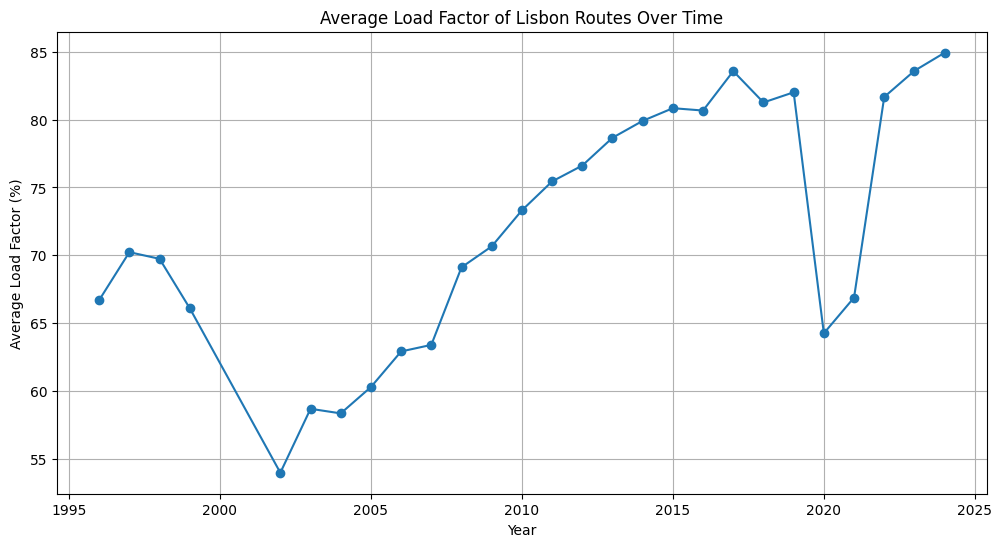

In [174]:
# =========================================================
# Average yearly load factor for Lisbon routes
# =========================================================

lisbon_load_factor = (
    general_df
    .groupby("year")["load_factor"]
    .mean()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    lisbon_load_factor.index,
    lisbon_load_factor.values,
    marker="o"
)

# =========================================================
# Labels and title
# =========================================================

plt.title("Average Load Factor of Lisbon Routes Over Time")

plt.xlabel("Year")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Grid
# =========================================================

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

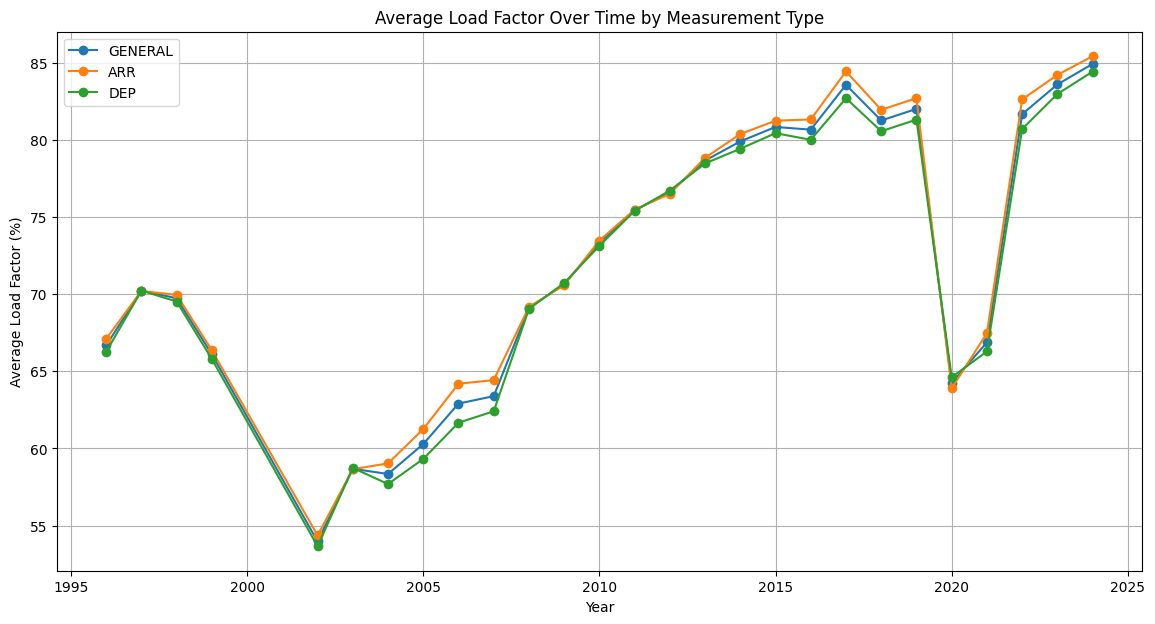

In [175]:
# =========================================================
# Compute yearly average load factor
# =========================================================

general_lf = (
    general_df
    .groupby("year")["load_factor"]
    .mean()
)

arr_lf = (
    arr_df
    .groupby("year")["load_factor"]
    .mean()
)

dep_lf = (
    dep_df
    .groupby("year")["load_factor"]
    .mean()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(14, 7))

plt.plot(
    general_lf.index,
    general_lf.values,
    marker="o",
    label="GENERAL"
)

plt.plot(
    arr_lf.index,
    arr_lf.values,
    marker="o",
    label="ARR"
)

plt.plot(
    dep_lf.index,
    dep_lf.values,
    marker="o",
    label="DEP"
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Average Load Factor Over Time by Measurement Type"
)

plt.xlabel("Year")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend()

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

### Evolution of Load Factor Over Time

The graph shows a clear long-term increase in the average load factor of flights connected to Lisbon airport, considering general traffic as well as arrivals (`ARR`) and departures (`DEP`).

Although data for 2000 and 2001 is missing, the series reveals a significant decrease beginning in 2002, when average load factors dropped to nearly 54%. A plausible explanation is the global impact of the September 11th attacks in 2001, which generated a strong decline in air travel demand and a widespread “panic effect” among passengers worldwide. This shock affected the aviation industry for several years and is visible in Lisbon’s traffic patterns as well.

After this downturn, the airport experienced a long and almost uninterrupted recovery phase. From the mid-2000s onward, load factors increased steadily year after year, indicating progressively fuller aircraft and stronger demand for flights connected to Lisbon. This growth became particularly evident after 2010, coinciding with the expansion of low-cost airlines, the rapid growth of tourism in Portugal, and Lisbon’s increasing popularity as an international destination.

The only major interruption to this positive trend occurred during the COVID-19 pandemic in 2020. The graph shows a sudden collapse in load factor across all measurement types due to travel restrictions, lockdowns, and the sharp reduction in international mobility. Interestingly, during this specific period, the load factor for arrivals became slightly lower than the load factor for departures — the opposite of what is generally observed in the rest of the timeline.

This pattern may suggest that Lisbon’s aviation demand is strongly tourism-driven, meaning the city tends to attract more incoming passengers than outgoing ones under normal circumstances. During the pandemic, international tourism almost disappeared, heavily affecting arrivals. However, this observation alone is not sufficient to conclusively prove that tourism is the dominant driver behind the imbalance between arrivals and departures. Additional analyses — such as passenger nationality, trip purpose, or tourism statistics — would be required to support that conclusion rigorously.

Overall, aside from major global disruptions such as 9/11 and COVID-19, the trend remains remarkably stable and consistently upward. By 2024, the average load factor exceeds 85%, meaning that flights operating to and from Lisbon are now running close to full capacity on average. This is a strong indicator of sustained pressure on the airport infrastructure and reinforces the broader discussion about whether Lisbon’s current airport capacity is sufficient for future demand.

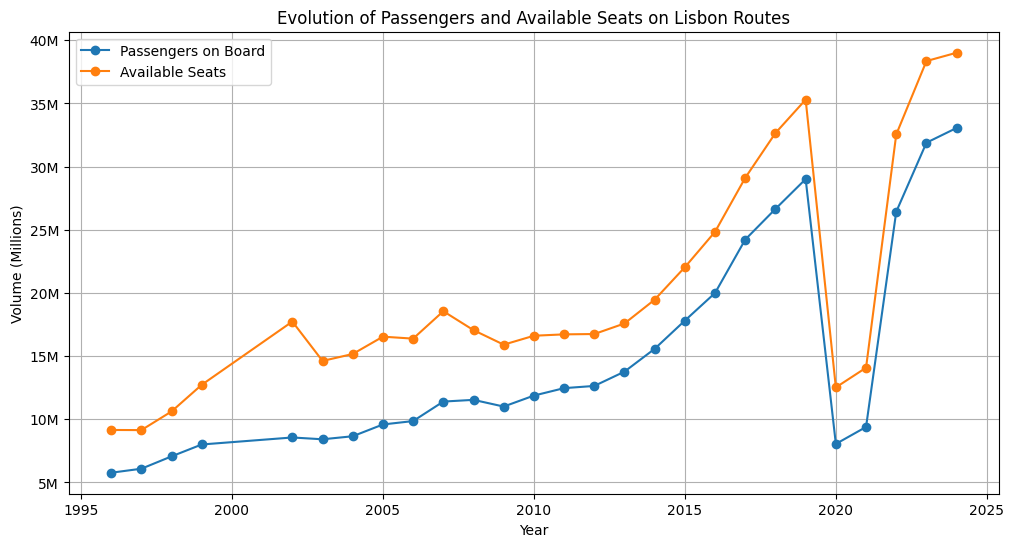

In [176]:
from matplotlib.ticker import FuncFormatter

# =========================================================
# Aggregate yearly passengers and seats
# =========================================================

traffic_evolution = (
    general_df
    .groupby("year")[["pas_brd", "st_pas"]]
    .sum()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    traffic_evolution.index,
    traffic_evolution["pas_brd"],
    marker="o",
    label="Passengers on Board"
)

plt.plot(
    traffic_evolution.index,
    traffic_evolution["st_pas"],
    marker="o",
    label="Available Seats"
)

# =========================================================
# Format Y axis in millions
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.0f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title("Evolution of Passengers and Available Seats on Lisbon Routes")

plt.xlabel("Year")

plt.ylabel("Volume (Millions)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend()

plt.grid(True)

# =========================================================
# Show plot
# =========================================================

plt.show()

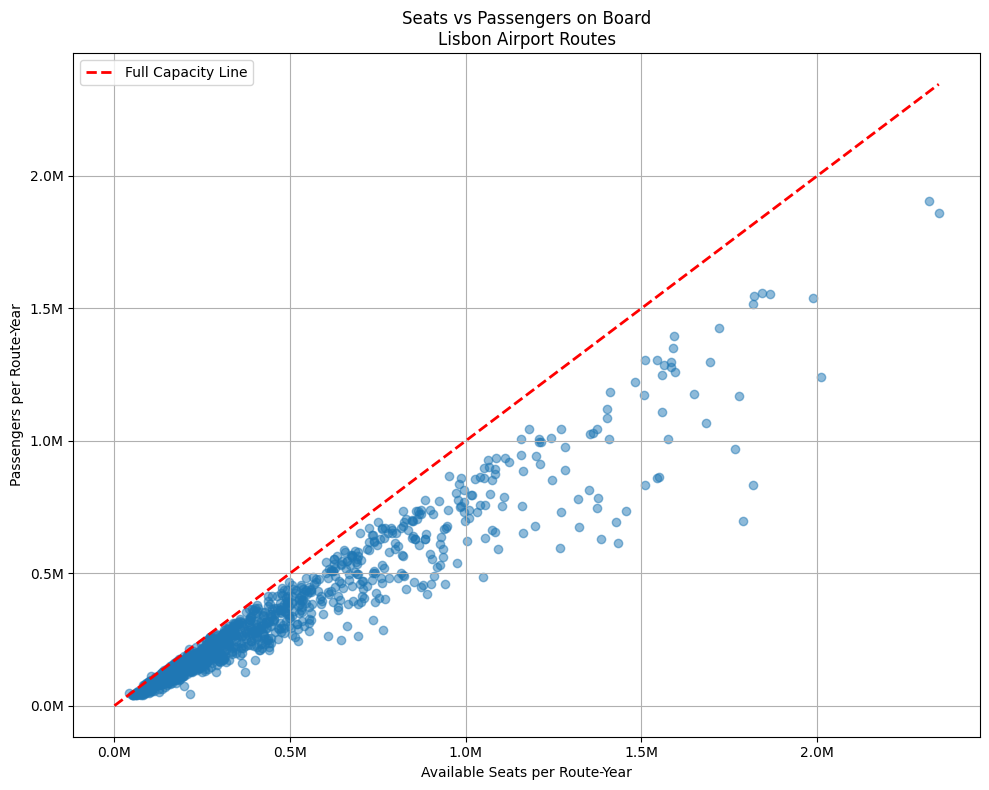

In [180]:
# Scatter plot: Seats vs Passengers
# =========================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    general_df["st_pas"],
    general_df["pas_brd"],
    alpha=0.5
)

# =========================================================
# Add diagonal reference line
# =========================================================

max_value = max(
    general_df["st_pas"].max(),
    general_df["pas_brd"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Full Capacity Line"
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Seats vs Passengers on Board\nLisbon Airport Routes"
)

plt.xlabel("Available Seats per Route-Year")

plt.ylabel("Passengers per Route-Year")

# =========================================================
# Grid and legend
# =========================================================

plt.grid(True)

plt.legend()

# =========================================================
# Format axes in millions
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f"{x/1_000_000:.1f}M"
)

plt.gca().xaxis.set_major_formatter(formatter)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Layout
# =========================================================


plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Relationship Between Passenger Demand and Available Capacity

These two graphs provide complementary perspectives on the relationship between passenger demand and seat availability on Lisbon airport routes. Together, they reveal a clear pattern: although airlines have continuously expanded capacity over time, demand has grown at a very similar pace, leading to increasingly high aircraft occupancy levels.

The first graph illustrates the long-term evolution of total passengers on board and available seats between 1996 and 2024. Both curves follow an almost parallel trajectory, especially after 2010, indicating that airlines consistently adjusted capacity in response to rising demand rather than generating excessive oversupply. As Lisbon became a stronger tourism and international mobility hub, airlines progressively increased frequencies, routes, and aircraft capacity to accommodate growing traffic.

The sharp expansion after 2014 is particularly significant. Passenger numbers rose from around 18 million to more than 33 million in less than a decade, while available seats increased from approximately 22 million to almost 39 million. This demonstrates not only rapid aviation growth, but also the airport’s increasing operational intensity.

The second graph reinforces this interpretation at the route-year level. Each point represents a specific route in a given year, comparing available seats with passengers transported. The red dashed line represents theoretical full capacity, where every available seat would be occupied.

Most observations are concentrated relatively close to this full-capacity line, showing a strong positive relationship between seat supply and actual passenger demand. In practice, routes with more available seats also tend to transport proportionally more passengers, suggesting that airlines are generally operating with efficient capacity allocation rather than maintaining large numbers of empty seats.

Another important observation is that very few points approach complete saturation. This indicates that airlines still maintain a safety margin between maximum capacity and effective occupancy, which is operationally necessary for flexibility and market stability. However, the density of points near the upper section of the graph suggests that many major routes are operating with relatively high occupancy levels, especially in recent years.

The COVID-19 pandemic appears clearly in the temporal evolution graph as an abrupt collapse in both passengers and available seats during 2020. Nevertheless, the recovery afterward is exceptionally rapid, with both variables surpassing pre-pandemic levels within only a few years. This reinforces the idea that Lisbon’s aviation demand is not temporary or purely cyclical, but structurally strong and increasingly sustained over time.

Taken together, these graphs suggest that the airport’s growth has not been driven simply by airlines artificially increasing supply. Instead, Lisbon appears to be experiencing genuine demand expansion, where increases in available capacity are consistently absorbed by passenger traffic. This dynamic contributes directly to the growing pressure on airport infrastructure and helps explain why discussions surrounding airport saturation and future expansion have intensified in recent years.

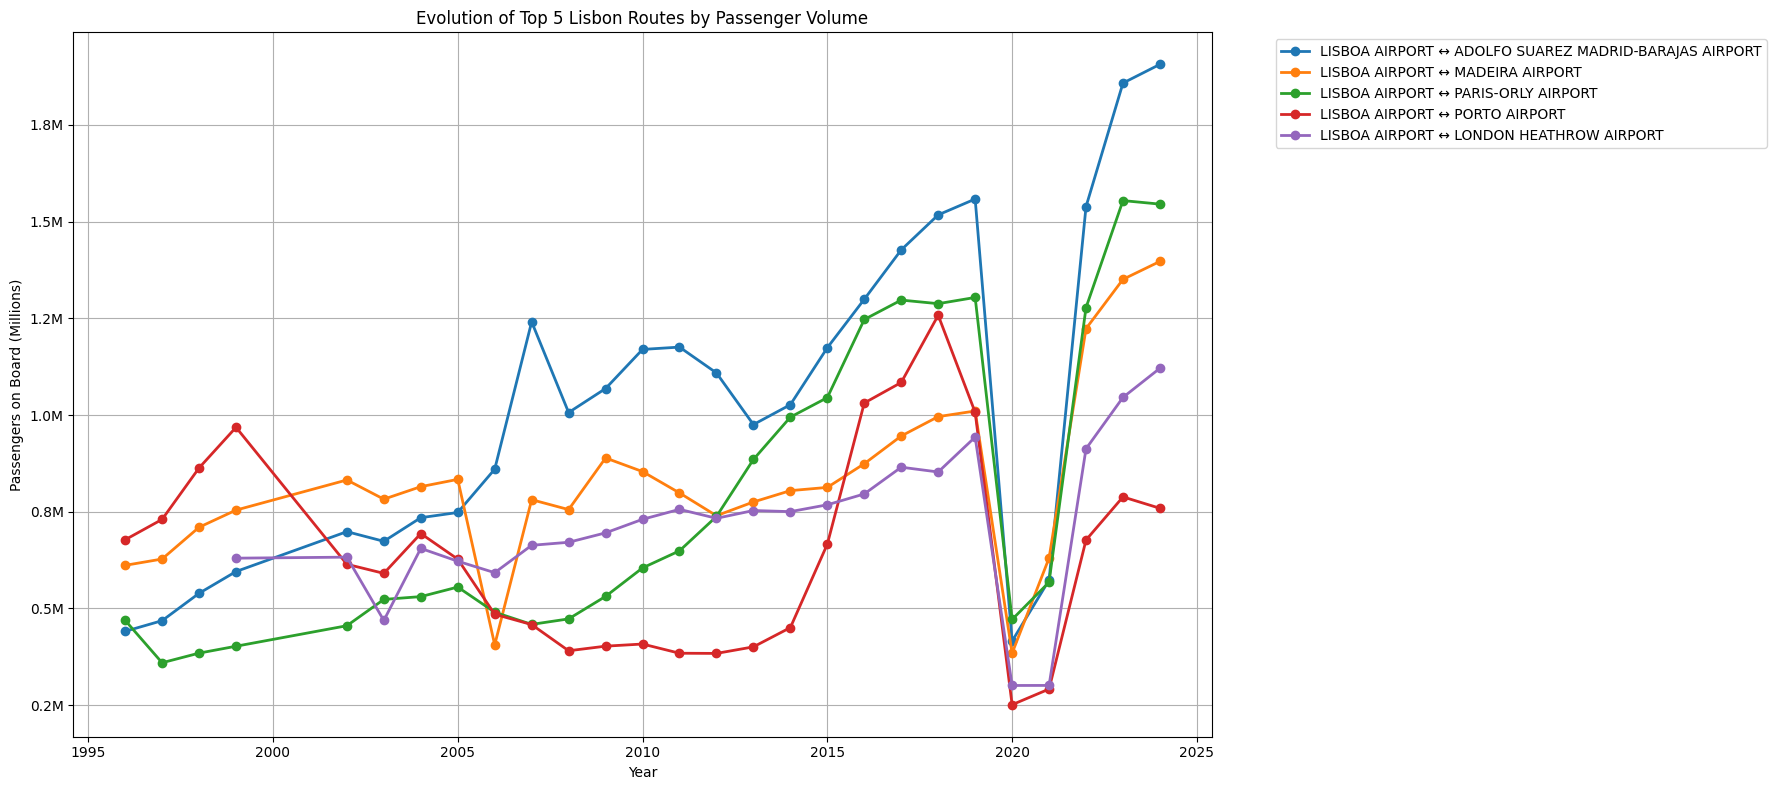

In [177]:
# =========================================================
# Identify top 5 routes by total passengers
# =========================================================

top_routes = (
    general_df
    .groupby("route")["pas_brd"]
    .sum()
    .nlargest(5)
    .index
)

# =========================================================
# Filter dataframe
# =========================================================

top_routes_df = general_df[
    general_df["route"].isin(top_routes)
]

# =========================================================
# Aggregate yearly passengers
# =========================================================

top_routes_yearly = (
    top_routes_df
    .groupby(
        ["year", "route"]
    )["pas_brd"]
    .sum()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(18, 8))

for route in top_routes:

    route_data = top_routes_yearly[
        top_routes_yearly["route"] == route
    ]

    plt.plot(
        route_data["year"],
        route_data["pas_brd"],
        marker="o",
        linewidth=2,
        label=route
    )

# =========================================================
# Format Y axis
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.1f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Evolution of Top 5 Lisbon Routes by Passenger Volume"
)

plt.xlabel("Year")

plt.ylabel("Passengers on Board (Millions)")

# =========================================================
# Legend and grid
# =========================================================

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Evolution of the Top 5 Lisbon Routes by Passenger Volume

This graph highlights the evolution of the five busiest routes connected to Lisbon airport in terms of passenger volume between 1996 and 2024. The selected routes reveal how Lisbon’s connectivity has progressively shifted toward a more international and tourism-oriented network.

The Lisbon–Madrid route consistently appears as the dominant connection throughout most of the timeline. Its strong and continuous growth reflects Madrid’s importance both as a business hub and as a major international connection point for Iberian and intercontinental flights. By 2024, this route exceeds 2 million passengers, making it the busiest route in the dataset.

The Paris-Orly route also shows remarkable long-term growth, especially after 2012. This increase is likely linked to the strong historical, economic, and migratory ties between Portugal and France, combined with the expansion of tourism flows between the two countries. By the end of the period, Paris-Orly becomes the second-largest route, reaching approximately 1.6 million passengers annually.

Routes connected to islands, particularly Madeira, maintain consistently high passenger volumes throughout the entire series. Unlike many continental routes that fluctuate more significantly according to economic conditions or tourism trends, island connections represent an essential mobility corridor for residents, tourism, and economic activity. The Madeira route therefore combines both tourism demand and structural transportation necessity.

The Lisbon–Porto route presents one of the most interesting patterns in the graph. During the late 1990s it was among the busiest routes, but passenger volumes declined substantially throughout the 2000s. A plausible explanation is the expansion and modernization of alternative transportation systems between the two cities, particularly the improvement of rail services and highway infrastructure, which reduced the competitiveness of domestic air travel on short distances. However, after 2015 the route partially recovered, possibly due to tourism growth and increased connecting traffic through Lisbon airport.

London Heathrow demonstrates a more stable and progressive trajectory. As one of Europe’s most important global hubs, Heathrow plays a key role in connecting Lisbon to long-haul international destinations. The route experiences strong growth after the pandemic recovery, surpassing 1 million passengers by 2024.

All routes display a dramatic collapse in 2020 due to the COVID-19 pandemic, followed by an exceptionally rapid rebound. In most cases, passenger volumes recovered to — and often surpassed — pre-pandemic levels within only a few years. This reinforces the idea that Lisbon’s air traffic demand remains structurally strong across different types of routes: business-oriented, tourism-oriented, domestic, and international.

Another important observation is the increasing dominance of international routes over domestic ones in recent years. Madrid, Paris, and London all show significantly stronger long-term growth compared to Porto, suggesting that Lisbon airport is becoming progressively more integrated into international tourism and global mobility networks rather than relying primarily on domestic traffic.

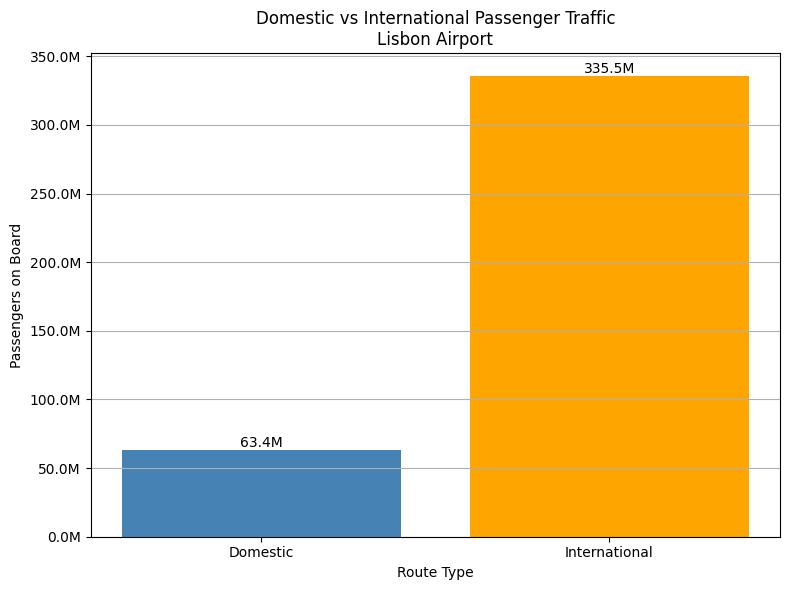

In [178]:
# =========================================================
# Create route type category
# =========================================================

general_df["route_type"] = np.where(
    general_df["airport2_code"].str.startswith("PT_"),
    "Domestic",
    "International"
)

# =========================================================
# Aggregate total passengers
# =========================================================

route_type_df = (
    general_df
    .groupby("route_type")["pas_brd"]
    .sum()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(8, 6))

plt.bar(
    route_type_df["route_type"],
    route_type_df["pas_brd"],
    color=["steelblue", "orange"]
)

# =========================================================
# Format Y axis
# =========================================================

formatter = FuncFormatter(
    lambda x, pos: f'{x/1_000_000:.1f}M'
)

plt.gca().yaxis.set_major_formatter(formatter)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Domestic vs International Passenger Traffic\nLisbon Airport"
)

plt.xlabel("Route Type")

plt.ylabel("Passengers on Board")

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(route_type_df["pas_brd"]):

    plt.text(
        index,
        value,
        f'{value/1_000_000:.1f}M',
        ha="center",
        va="bottom"
    )

# =========================================================
# Grid
# =========================================================

plt.grid(axis="y")

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

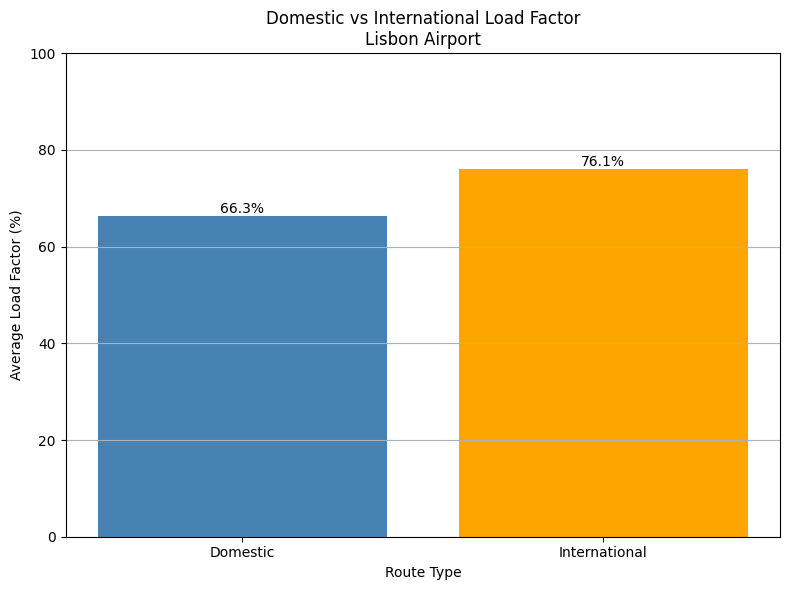

In [179]:
# =========================================================
# Aggregate average load factor
# =========================================================

route_type_lf_df = (
    general_df
    .groupby("route_type")["load_factor"]
    .mean()
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(8, 6))

plt.bar(
    route_type_lf_df["route_type"],
    route_type_lf_df["load_factor"],
    color=["steelblue", "orange"]
)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Domestic vs International Load Factor\nLisbon Airport"
)

plt.xlabel("Route Type")

plt.ylabel("Average Load Factor (%)")

# =========================================================
# Y-axis limits
# =========================================================

plt.ylim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(route_type_lf_df["load_factor"]):

    plt.text(
        index,
        value,
        f'{value:.1f}%',
        ha="center",
        va="bottom"
    )

# =========================================================
# Grid
# =========================================================

plt.grid(axis="y")

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Domestic vs International Traffic at Lisbon Airport

These graphs clearly reinforce one of the central findings of the analysis: Lisbon airport depends overwhelmingly on international air traffic, both in terms of passenger volume and infrastructure utilization.

The first chart shows a massive imbalance between domestic and international passenger traffic. International routes account for approximately **335.5 million passengers**, while domestic routes represent only **63.4 million passengers** across the analyzed period. In practice, this means that the airport’s activity is driven primarily by international mobility rather than internal Portuguese connectivity.

This result is consistent with the previous route-level analysis. International connections such as Madrid, Paris-Orly, and London Heathrow have experienced much stronger and more sustained growth over time compared to domestic routes like Porto. While domestic aviation remains important, especially for island connections such as Madeira and the Azores, the long-term expansion of Lisbon airport is fundamentally linked to tourism, international business travel, and Lisbon’s growing role as a European destination and transit hub.

The second graph adds another important dimension to this interpretation. International routes not only transport far more passengers, but they also operate with significantly higher load factors. International flights reach an average load factor of approximately **76.1%**, compared to only **66.3%** for domestic flights.

This indicates that international routes are considerably more saturated, meaning airlines are filling a much larger proportion of the available seats on these flights. In operational terms, this suggests stronger and more concentrated demand pressure on the airport’s international network.

Several factors may explain this difference:

- International tourism demand toward Lisbon has increased dramatically over the last decade.
- Lisbon functions as a gateway city connecting Europe, the Americas, and parts of Africa.
- Domestic routes face stronger competition from alternative transportation systems, particularly rail and highway infrastructure between Lisbon and Porto.
- Many domestic flights operate partly for territorial cohesion and connectivity purposes, especially island routes, which may reduce the pressure to maximize seat occupancy compared to highly competitive international routes.

Taken together, these results suggest that the debate surrounding airport overcapacity is primarily an international traffic issue rather than a domestic one. The strongest pressure on Lisbon airport infrastructure appears to originate from international demand, which is both substantially larger and consistently more capacity-intensive.

This also helps explain why the busiest and fastest-growing routes in the dataset are predominantly international. Lisbon airport is progressively evolving from a mainly national airport into an international mobility hub heavily dependent on tourism and global connectivity.

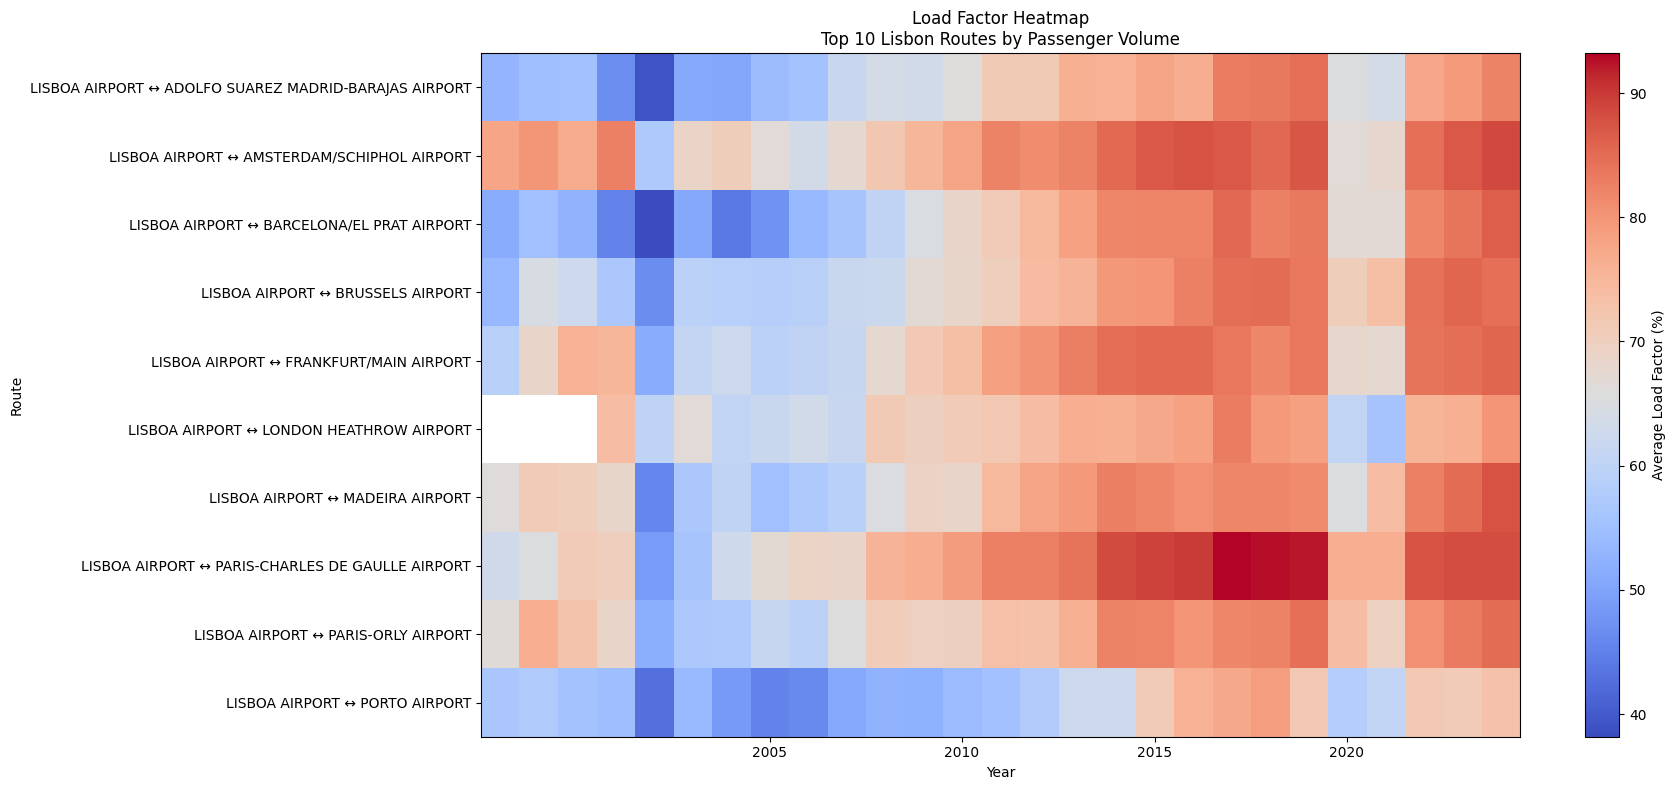

In [181]:
# =========================================================
# Identify top 10 routes by total passengers
# =========================================================

top_routes = (
    general_df
    .groupby("route")["pas_brd"]
    .sum()
    .nlargest(10)
    .index
)

# =========================================================
# Create pivot table for heatmap
# =========================================================

heatmap_df = (
    general_df[
        general_df["route"].isin(top_routes)
    ]
    .pivot_table(
        index="route",
        columns="year",
        values="load_factor",
        aggfunc="mean"
    )
)

# =========================================================
# Plot heatmap
# =========================================================

plt.figure(figsize=(18, 8))

im = plt.imshow(
    heatmap_df,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm"
)

# =========================================================
# Colorbar
# =========================================================

cbar = plt.colorbar(im)

cbar.set_label("Average Load Factor (%)")

# =========================================================
# Axis labels and ticks
# =========================================================

plt.title(
    "Load Factor Heatmap\nTop 10 Lisbon Routes by Passenger Volume"
)

plt.xlabel("Year")

plt.ylabel("Route")

# Y-axis labels
plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

# X-axis labels every 5 years
years = heatmap_df.columns

x_positions = [
    i for i, year in enumerate(years)
    if year % 5 == 0
]

x_labels = [
    year for year in years
    if year % 5 == 0
]

plt.xticks(
    x_positions,
    x_labels
)

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Load Factor Heatmap of the Top Lisbon Routes

This heatmap provides a detailed view of how the average load factor evolved over time for the ten busiest routes connected to Lisbon airport. Each row represents a route, while each column corresponds to a year. Warmer colors (orange/red) indicate higher load factors and therefore greater seat occupancy, whereas cooler colors (blue) indicate lower occupancy levels.

Several important patterns emerge from the visualization.

First, there is a clear long-term transition from cooler to warmer colors across almost all routes. This indicates that flights connected to Lisbon have become progressively more crowded over time, reinforcing the broader conclusion that demand growth has consistently outpaced or closely matched increases in available capacity.

The early 2000s show noticeably lower load factors across many routes, particularly around 2002–2003. This aligns with the broader slowdown in global aviation following the September 11th attacks and the temporary decline in international air travel demand.

From approximately 2010 onward, most international routes begin to display consistently high load factors, often exceeding 80%. This trend is especially visible on routes such as:

- Paris Charles de Gaulle
- Amsterdam Schiphol
- Frankfurt/Main
- Madrid-Barajas
- Barcelona El Prat

These routes increasingly operate near high occupancy levels, suggesting strong structural demand linked to tourism, business mobility, and Lisbon’s growing integration into major European aviation networks.

Paris Charles de Gaulle stands out as one of the most saturated routes in the dataset, reaching load factors above 90% in some years. This suggests extremely efficient seat utilization and sustained passenger demand over time.

In contrast, domestic routes — especially Porto — maintain significantly lower load factors throughout much of the timeline. Even though the Lisbon–Porto route remains important, it rarely reaches the occupancy levels observed on major international connections. This supports previous findings suggesting that domestic aviation faces stronger competition from alternative transportation systems such as railways and highways, reducing pressure on air travel demand between the two cities.

Island routes such as Madeira occupy an intermediate position. Their load factors increase steadily over time and eventually reach levels comparable to international routes. This likely reflects the dual role of these routes as both tourism corridors and essential territorial connectivity links.

The COVID-19 pandemic is clearly visible in 2020 and 2021, where nearly all routes experience abrupt decreases in load factor. However, the recovery afterward is extremely rapid. By 2023 and 2024, many routes not only recover but return to historically high occupancy levels.

Overall, the heatmap strongly reinforces the idea that the increasing pressure on Lisbon airport is driven primarily by highly saturated international routes. The persistence of high load factors across multiple major European destinations suggests that Lisbon’s aviation growth is not concentrated in a single market, but distributed across a broad international network with consistently strong demand.

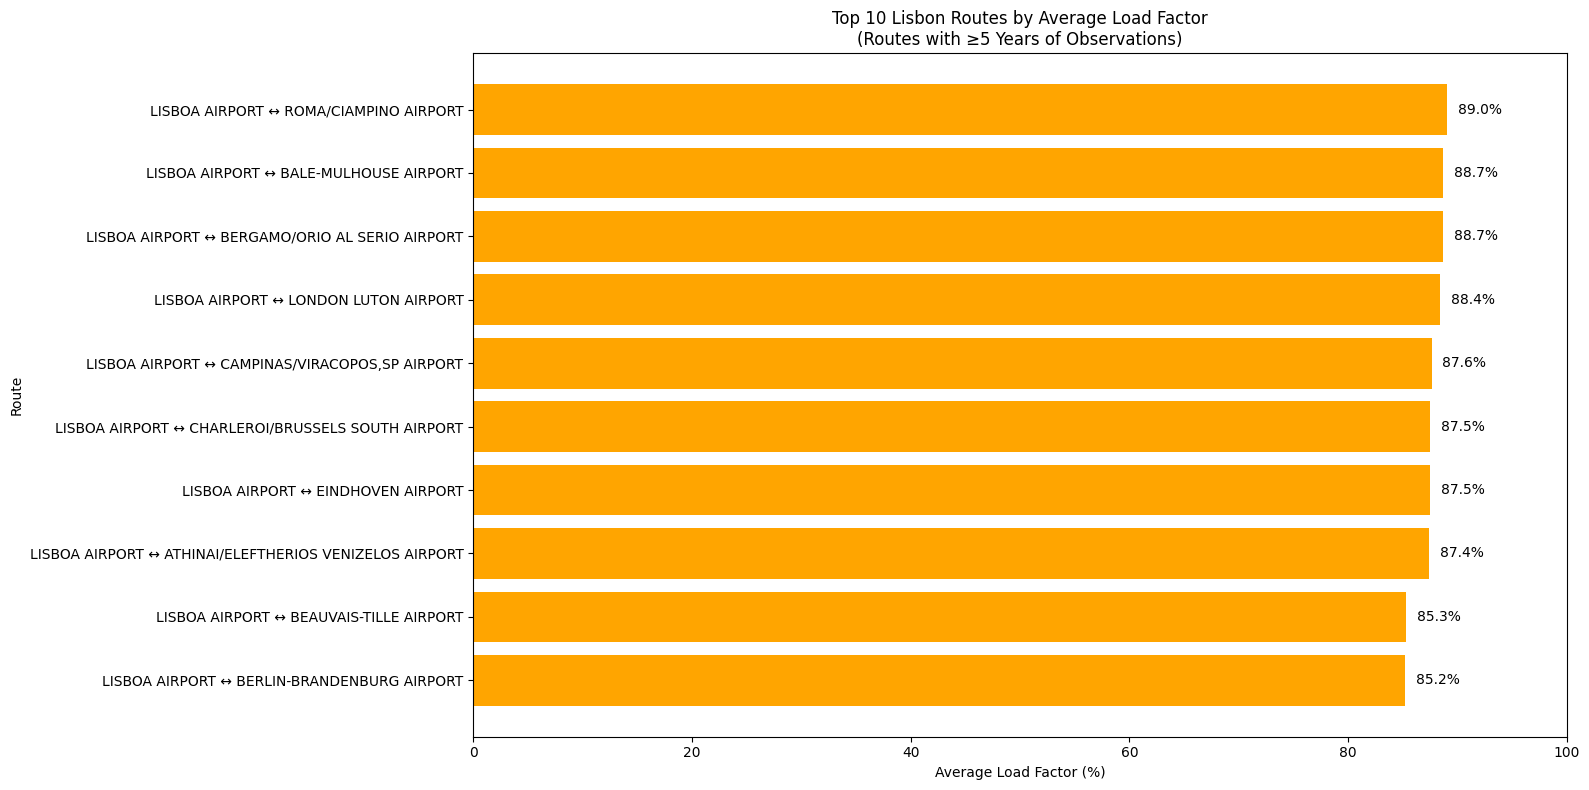

In [199]:
# =========================================================
# Find routes with at least 5 years of observations
# =========================================================

valid_routes = (
    general_df
    .groupby("route")["year"]
    .nunique()
)

valid_routes = valid_routes[
    valid_routes >= 5
].index

# =========================================================
# Filter dataframe
# =========================================================

filtered_df = general_df[
    general_df["route"].isin(valid_routes)
]

# =========================================================
# Calculate average load factor per route
# =========================================================

top_routes_lf = (
    filtered_df
    .groupby("route")["load_factor"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(16, 8))

plt.barh(
    top_routes_lf["route"],
    top_routes_lf["load_factor"],
    color="orange"

)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Top 10 Lisbon Routes by Average Load Factor\n(Routes with ≥5 Years of Observations)"
)

plt.xlabel("Average Load Factor (%)")

plt.ylabel("Route")

# =========================================================
# X-axis limits
# =========================================================

plt.xlim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(top_routes_lf["load_factor"]):

    plt.text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center"
    )

# =========================================================
# Improve readability
# =========================================================

plt.gca().invert_yaxis()

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

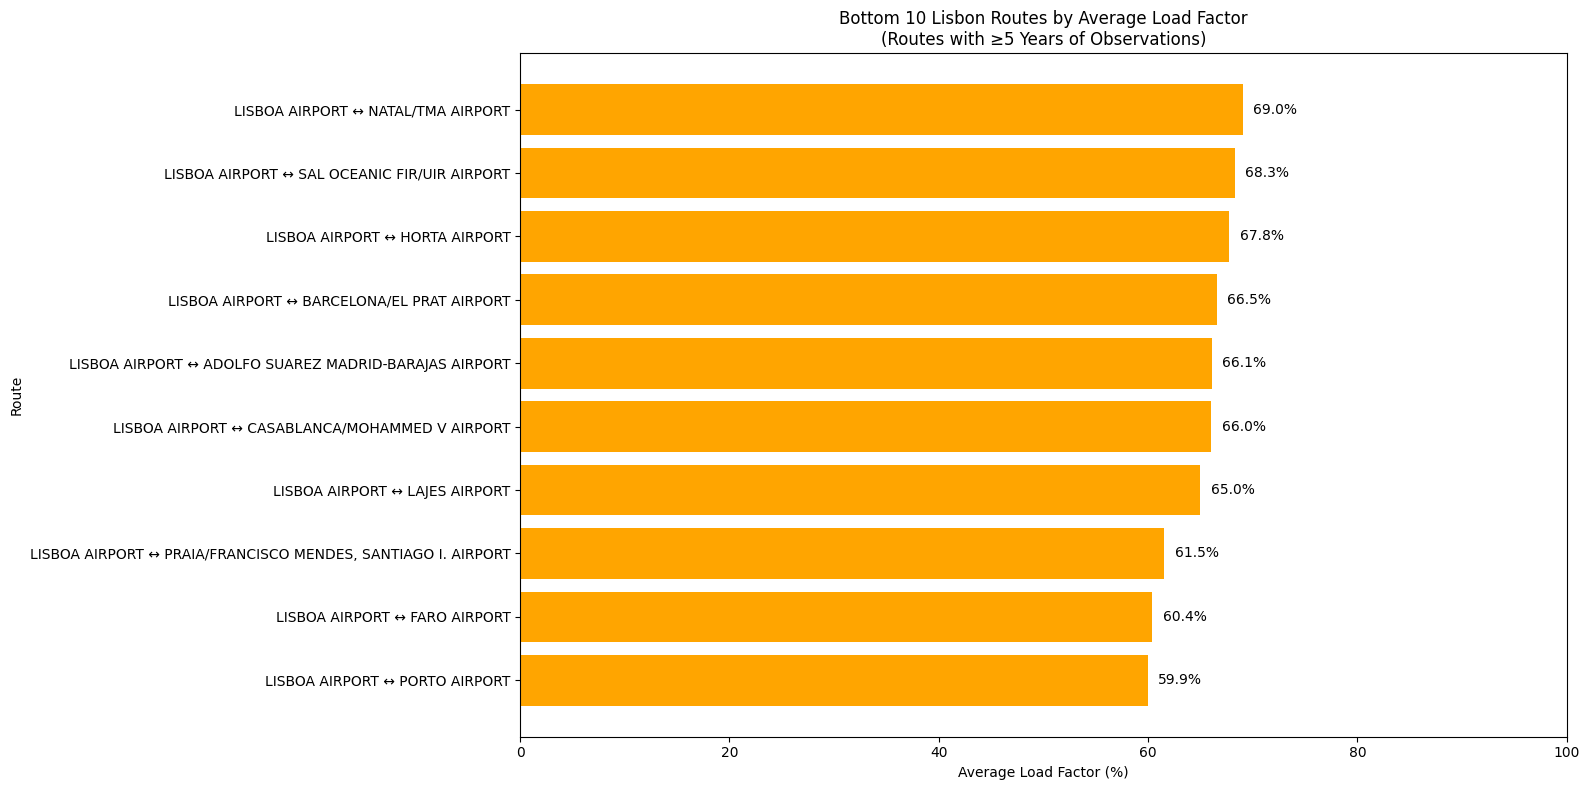

In [200]:
# =========================================================
# Calculate average load factor per route
# =========================================================

top_routes_lf = (
    filtered_df
    .groupby("route")["load_factor"]
    .mean()
    .sort_values(ascending=False)
    .tail(10)
    .reset_index()
)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(16, 8))

plt.barh(
    top_routes_lf["route"],
    top_routes_lf["load_factor"],
    color="orange"

)

# =========================================================
# Labels and title
# =========================================================

plt.title(
    "Bottom 10 Lisbon Routes by Average Load Factor\n(Routes with ≥5 Years of Observations)"
)

plt.xlabel("Average Load Factor (%)")

plt.ylabel("Route")

# =========================================================
# X-axis limits
# =========================================================

plt.xlim(0, 100)

# =========================================================
# Add value labels
# =========================================================

for index, value in enumerate(top_routes_lf["load_factor"]):

    plt.text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center"
    )

# =========================================================
# Improve readability
# =========================================================

plt.gca().invert_yaxis()

# =========================================================
# Layout
# =========================================================

plt.tight_layout()

# =========================================================
# Show
# =========================================================

plt.show()

### Comparison Between the Highest and Lowest Load Factor Routes

These two graphs highlight a strong contrast between the most saturated and the least saturated routes connected to Lisbon airport. The comparison reveals important differences in the nature of demand across Lisbon’s aviation network.

The routes with the highest average load factors are entirely international and strongly associated with tourism flows, low-cost travel demand, or major European mobility corridors. Connections such as Rome Ciampino, London Luton, Bergamo, Charleroi, Eindhoven, and Beauvais are all airports heavily used by low-cost carriers and leisure-oriented travelers.

Most of these routes maintain average load factors close to or above 85%, indicating extremely efficient seat utilization and consistently strong passenger demand. Airlines operating on these routes appear capable of filling a very large proportion of available seats over long periods of time.

This pattern strongly reinforces the idea that Lisbon’s airport pressure is driven primarily by international demand, especially tourism-related and low-cost international traffic.

In contrast, the routes with the lowest average load factors are dominated by domestic connections and peripheral territorial routes, particularly:

- Porto
- Faro
- Horta
- Lajes
- Other Atlantic/island routes

The Lisbon–Porto route, despite being one of the country’s most important mobility corridors, records the lowest average load factor in the ranking at approximately 60%. Faro also shows relatively low occupancy levels.

A likely explanation is the strong competition from alternative transportation systems on domestic mainland routes. The relatively short distances between Lisbon, Porto, and Faro make air travel less competitive compared to cheaper and more flexible alternatives such as:

- Intercity trains
- Private cars
- Long-distance buses
- Low-cost coach operators such as FlixBus

In recent years, companies like FlixBus have rapidly expanded in Portugal, offering extremely low prices and high-frequency connections between major Portuguese cities. This likely reduced pressure on domestic aviation demand, particularly for routes where travel times by land remain relatively manageable.

At the same time, several low-load-factor routes correspond to island or peripheral territories where flights are maintained partly for territorial cohesion and accessibility rather than purely for profitability or maximum occupancy optimization. In these cases, maintaining connectivity may be strategically more important than maximizing seat utilization.

Another interesting observation is that some extremely high-volume routes — such as Madrid-Barajas and Barcelona El Prat — still appear among the lower load-factor rankings. This suggests that high passenger volume alone does not necessarily imply high occupancy rates. These routes may operate with very large flight frequencies and substantial seat availability, creating more capacity relative to demand compared to ultra-efficient low-cost routes.

Overall, these graphs reveal a clear structural divide within Lisbon’s route network:

- International leisure and low-cost routes tend to operate with very high occupancy and saturation levels.
- Domestic mainland routes generally operate with lower load factors due to shorter distances and competition from alternative transportation modes.
- Peripheral and island routes fulfill broader territorial and connectivity functions beyond pure demand efficiency.

This distinction is essential for understanding where the real pressure on Lisbon airport infrastructure originates: not from domestic connectivity, but primarily from highly saturated international demand.

# Conclusion

The analyses conducted throughout this project suggest that Lisbon Airport operates under substantial and continuously increasing demand pressure, particularly on its major international routes. Passenger volumes, route density, and consistently high load factors indicate that Lisbon has strengthened its role as a major international aviation hub over the last two decades.

Several visualizations — including route evolution plots, heatmaps, bar plots, and scatter plots — reveal that many strategic international routes operate with very high seat occupancy levels over long periods of time. Routes connected to major European hubs and low-cost international destinations frequently reach load factors above 80–85%, suggesting sustained and structurally strong demand.

At the same time, the analyses also reveal an important imbalance between international and domestic traffic dynamics. International routes not only account for the overwhelming majority of passenger traffic, but also exhibit significantly higher average load factors compared to domestic routes. This suggests that the strongest operational pressure on Lisbon Airport infrastructure originates primarily from international tourism and international mobility demand rather than domestic connectivity.

In contrast, several domestic continental routes — particularly Lisbon–Porto and Lisbon–Faro — consistently appear among the routes with the lowest average load factors despite maintaining substantial seat capacity and operational frequency.

One possible explanation is the increasing competitiveness of alternative transportation systems within mainland Portugal. The relatively short distances between major Portuguese cities, combined with the expansion of rail infrastructure and low-cost coach operators such as FlixBus, may reduce the attractiveness of domestic air travel while still consuming valuable airport slots and operational resources.

The results therefore suggest that part of Lisbon Airport’s congestion problem may not derive exclusively from insufficient infrastructure capacity, but also from the current allocation and utilization of air traffic operations. Several optimization strategies could potentially reduce operational pressure before requiring full-scale airport expansion, including:

- reducing frequencies on persistently underutilized routes,
- resizing aircraft capacity on low-demand connections,
- improving seasonal scheduling efficiency,
- reallocating airport slots toward higher-demand international routes,
- and strengthening intermodal integration with rail and long-distance bus transportation.

However, the analyses also indicate that optimization alone may not fully solve Lisbon’s long-term capacity challenges. The sustained growth of international passenger demand, the rapid post-pandemic recovery, and the increasingly high saturation levels observed across major international routes suggest that pressure on airport infrastructure is likely to intensify further in the coming years.

Overall, the project supports a balanced conclusion: while a new airport may eventually become necessary in the long term, significant opportunities for operational optimization and traffic reallocation still exist and should be carefully explored before undertaking large-scale infrastructure investments.